# Analyse CMB/BAO/SNe chains for paper

In [53]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
import getdist
from getdist import plots, MCSamples
from cobaya.yaml import yaml_load_file

In [55]:
import numpy as np, glob, healpy as H, os, sys, re
from getdist.gaussian_mixtures import Gaussian1D, Gaussian2D, GaussianND
import pandas as pd
from itertools import chain


#sys.path.append('/Users/sraghunathan/Research/SPTpol/analysis/git/CMB_SNIa_3x2pt_Fisher/modules/')
from pylab import *

sys.path.append('modules/')
import sne_cmb_fisher_tools, misc
import misc_getdist

import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger().setLevel(logging.ERROR)

In [56]:
rcParams['figure.dpi'] = 150
rcParams['figure.facecolor'] = 'white'
rcParams['font.family'] = 'serif'

#plot(); show()

In [63]:
#some specs / variables
burn_in_fraction = 0.3
chain_fd = 'chains/for_paper/'


paramfile = 'data/params_cobaya.ini'
param_dict = misc.get_param_dict(paramfile)
param_dict['H0'] = param_dict['h'] * 100.
param_dict['omegam'] = param_dict['omch2'] / param_dict['h']**2. + param_dict['ombh2'] / param_dict['h']**2.
param_dict['logA'] = np.log( 1e10 * param_dict['As'] )

pl_folder = 'plots/'
if not os.path.exists( pl_folder ): os.system('mkdir -p %s' %(pl_folder))

# DESI DR3 improvement plots for the paper




desidr2bao_mock-lcdm (14980, 20)
desidr3bao_highz_mock-lcdm (16968, 20)
desidr3bao_lowz_mock-lcdm (40656, 20)
desidr3bao_lowz_mock+desidr3bao_highz_mock-lcdm (18816, 21)


desidr2bao_mock-lcdm 416.15528830277765
desidr3bao_highz_mock-lcdm 87.86278580756495
desidr3bao_lowz_mock-lcdm 695.8352392554593
desidr3bao_lowz_mock+desidr3bao_highz_mock-lcdm 1032.0801958171826


<Figure size 900x600 with 0 Axes>

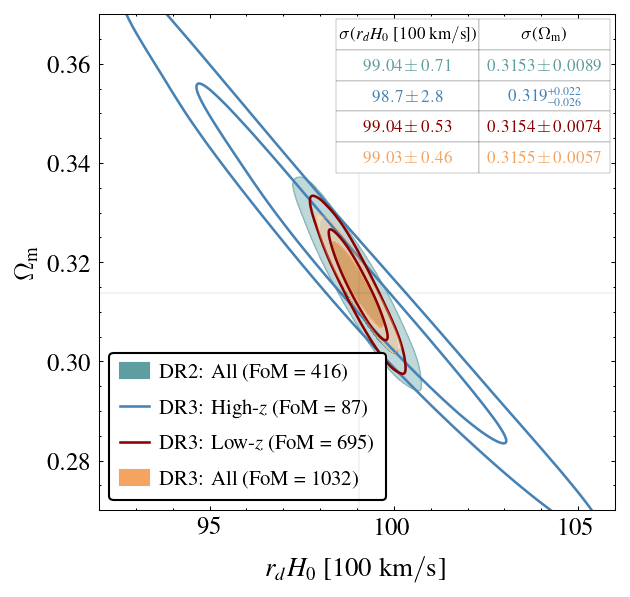

In [75]:
import copy
chain_fd = 'chains/for_paper/'
param_limits_dic = {'omegam': [0.27, 0.37], 
                    'rdh': [92., 106.], 
                    'w': [-1.5, 1], 
                    'wa': [-4., 1.], 
                    'mnu': [0., 0.2], 
                    'nnu': [2.8, 3.4], 
                    'H0': [66., 69.], 
                   }

for desi_iter in range(1):#2):
    print('\n\n')
    if desi_iter == 0:
        #get all the samples for w0wamnulcdm 
        chain_fdlist = ['desidr2bao_mock-lcdm', 'desidr3bao_highz_mock-lcdm', 'desidr3bao_lowz_mock-lcdm', 'desidr3bao_lowz_mock+desidr3bao_highz_mock-lcdm']
        label_dic = {'desidr3bao_highz_mock-lcdm': r'DR3: High-$z$',# Ly-$\alpha$', 
                     'desidr3bao_lowz_mock-lcdm': r'DR3: Low-$z$', 
                     'desidr3bao_lowz_mock+desidr3bao_highz_mock-lcdm': r'DR3: All', 
                     'desidr2bao_mock-lcdm': r'DR2: All'}
        plname = 'plots/desi_dr2_dr3_rdh_omegam.pdf'
        params_to_plot = [['rdh', 'omegam']]
    else:
        chain_fdlist = ['desidr2bao_mock-w0walcdm', 'desidr3bao_highz_mock-w0walcdm', 'desidr3bao_lowz_mock-w0walcdm', 'desidr3bao_lowz_mock+desidr3bao_highz_mock-w0walcdm']
        label_dic = {'desidr3bao_highz_mock-w0walcdm': r'DR3: High-$z$',# Ly-$\alpha$', 
                     'desidr3bao_lowz_mock-w0walcdm': r'DR3: Low-$z$', 
                     'desidr3bao_lowz_mock+desidr3bao_highz_mock-w0walcdm': r'DR3: All', 
                     'desidr2bao_mock-w0walcdm': r'DR2: All'}
        plname = 'plots/desi_dr2_dr3_w0_wa.pdf'
        params_to_plot = [['w', 'wa']]

    color_arr = []
    samples_dic = {}
    for curr_chain_fd in chain_fdlist:
        curr_chain_fd = 'chains/for_paper/%s' %(curr_chain_fd)

        chainname = curr_chain_fd.split('/')[-1]
        fname = '%s/%s' %(curr_chain_fd, chainname)

        chainfile = '%s.1.txt' %(fname)
        if not os.path.exists( chainfile ): continue

        curr_samples = getdist.mcsamples.loadMCSamples( fname )
        curr_samples.removeBurn(burn_in_fraction)

        if (1):
            p = curr_samples.getParams()
            paramnames = curr_samples.getParamNames()
            curr_samples.addDerived(p.rdrag * p.H0/100., name='rdh', label=r'r_{d}H_{0}\ [100\ {\rm km/s}]')
            param_dict['rd'] = 147.0330237648529
            param_dict['rdh'] = param_dict['rd'] * param_dict['H0']/100.

        samples_dic[chainname] = curr_samples
        print( chainname, curr_samples.samples.shape )
        
    #color_arr = ['sandybrown', 'tab:green', 'black']

    chains_to_plot = chain_fdlist
    filled = [True, False, False, True]
    #color_arr = ['sandybrown', 'steelblue', 'darkred', 'black']
    color_arr = ['cadetblue', 'steelblue', 'darkred', 'sandybrown']

    print('\n')
    samples_to_plot, labels_arr = [], []
    for chainname in chains_to_plot:
        ###print(chainname)
        curr_samples = samples_dic[chainname]
        samples_to_plot.append( curr_samples )
        #chain_label = misc_getdist.get_chain_label(chainname, remove_cmb_datachars = True).split('+')[0]

        cov_mat = misc_getdist.get_param_cov_mat_from_getdist(curr_samples, params_to_plot[0])
        fom = 1/np.sqrt( np.linalg.det(cov_mat) )

        print( chainname, fom )

        chain_label = label_dic[chainname]
        #labels_arr.append( chain_label )  
        labels_arr.append( '%s (FoM = %d)' %(chain_label, fom) )    

    g = misc_getdist.make_getdist_plot('plots_2d',
                                       samples_to_plot, 
                                       params_to_plot, 
                                       param_dict = param_dict, 
                                       param_limits_dic = param_limits_dic,
                                       color_arr = color_arr, 
                                       figsize = 4.3, fsval = 12, legfsval = 10.,# 11,
                                       labels = labels_arr, legloc = 'lower left', legcol = 1,
                                       scaling = True,#, wspace = 0.05
                                       xyloc_for_leg = [0.68, 0.95], 
                                       filled = filled,
                                       #linestyle = '-.',
                                      )
    curr_ax = g.get_axes()
    constraints_dic, constraints_table, colors_table, col_labels = misc_getdist.get_constraints_table(params_to_plot[0], samples_to_plot, color_arr)
    curr_table_locs = 0.46, 0.68
    curr_table_width = 0.53, 0.31
    curr_table_col_width = [0.52, 0.48]
    curr_table_fontsize = 8.2
    tx, ty = curr_table_locs
    tab_width, tab_height = curr_table_width
    table = curr_ax.table(cellText=constraints_table, 
                    colLabels=col_labels, cellLoc = 'center', 
                    bbox = (tx, ty, tab_width, tab_height), 
                    #cellColours = colors_table, 
                    colWidths = curr_table_col_width, 
                    alpha = 1., 
                    zorder = 100.,
                    #edges = 'BT',
                    )
    # Disable auto font size
    table.auto_set_font_size(False)
    table.set_zorder(100)

    # Set the font size
    table.set_fontsize(curr_table_fontsize)

    for cellkey in table.get_celld():
        table[cellkey].set_linewidth(0.1)
        if cellkey[0] == 0: continue #header
        colorval = colors_table[cellkey[0]-1, 0]
        #print(cellkey, colorval, table[cellkey].get_text())
        table[cellkey].get_text().set_color(colorval)

    #show(); sys.exit()
    
    savefig(plname, dpi = 200.)
    show();
    


# w0waLCDM parameter constraints: DES vs LSST

Total chains to analyse = 3

dict_keys(['lssty3snesim1_w0walcdm', 'lssty3_sne_mock_binned-w0walcdm', 'desy5sne_w0walcdm'])
desy5sne_w0walcdm 95.25037470279277 1.7016529381006595
lssty3_sne_mock_binned-w0walcdm 493.799100245622 9.071611551654328
lssty3snesim1_w0walcdm 1014.4355175095693 15.53060860117125


<Figure size 900x600 with 0 Axes>

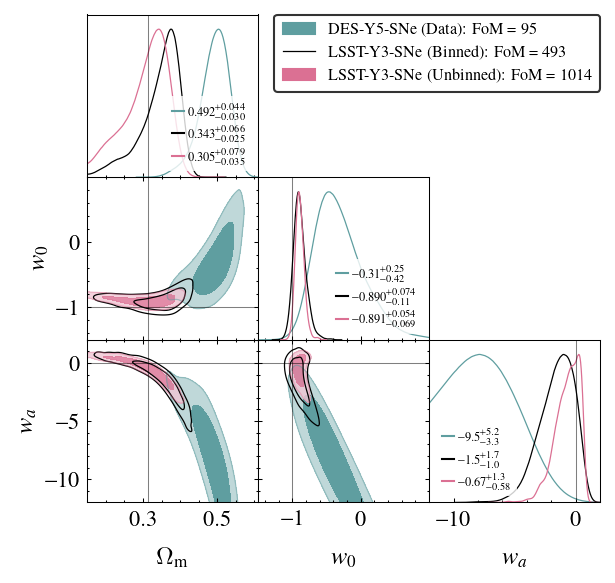

In [32]:
which_cosmo = 'w0walcdm'
#which_cosmo = 'lcdm'
chain_fd = 'chains/for_paper/'
'''
chain_search_str = '%s/lsst*-%s' %(chain_fd, which_cosmo)
chain_fdlist = glob.glob( chain_search_str )
'''

other_mcmc_fd = '/Users/sraghunathan/Research/cobaya/desi/chains/'
chain_fdlist = ['%s/lssty3snesim1_%s' %(other_mcmc_fd, which_cosmo), 
                '%s/lssty3_sne_mock_binned-%s' %(chain_fd, which_cosmo), 
               ]


#add DES-Y5
des_y5_chain_fd = '/Users/sraghunathan/Research/cobaya/desi/chains/desy5sne_%s' %(which_cosmo)
chain_fdlist.append( des_y5_chain_fd )
#des_y5_sim_chain_fd = '/Users/sraghunathan/Research/cobaya/desi/chains/desy5snesim_%s' %(which_cosmo)
#chain_fdlist.append( des_y5_sim_chain_fd )


print('Total chains to analyse = %s\n' %(len(chain_fdlist)))

samples_dic = {}
for curr_chain_fd in chain_fdlist:
    chainname = curr_chain_fd.strip('/').split('/')[-1]
    fname = '%s/%s' %(curr_chain_fd, chainname)
    ###print(chainname, fname)

    chainfile = '%s.1.txt' %(fname)
    if not os.path.exists( chainfile ): continue
        
        
    curr_samples = getdist.mcsamples.loadMCSamples( fname )
    curr_samples.removeBurn(burn_in_fraction)
    samples_dic[chainname] = curr_samples
    #print( chainname, chain_label, curr_samples.samples.shape )

print(samples_dic.keys()); ##sys.exit()
clf()
params_to_plot = ['omegam', 'w', 'wa']; fsval = 15; figsize = 4.2; legfsval = 12.
#params_to_plot = ['omegam', 'w', 'wa']; fsval = 16; figsize = 4.5; legfsval = 14.5

if which_cosmo == 'lcdm':
    params_to_plot = ['omegam']
chains_to_plot = [
                  'desy5sne_%s' %(which_cosmo), 
                  ###'desy5snesim_%s' %(which_cosmo), 
                  #'lssty3_sne_mock-%s' %(which_cosmo),
                  'lssty3_sne_mock_binned-%s' %(which_cosmo),
                  'lssty3snesim1_%s' %(which_cosmo),
    
]
samples_to_plot, labels_arr = [], []
for chainname in chains_to_plot:
    curr_samples = samples_dic[chainname]
    samples_to_plot.append( curr_samples )
    chain_label = misc_getdist.get_chain_label(chainname)
    chain_label = chain_label.replace('TTEETEPP', r'\texttt{TT/EE/TE/$\phi\phi$}')
    chain_label = chain_label.replace('+', ' + ')
    if chain_label == 'LSST-Y3-SNe':
        chain_label = '%s (Unbinned)' %(chain_label)
    cov_mat = misc_getdist.get_param_cov_mat_from_getdist(curr_samples, params_to_plot)
    fom = 1/np.sqrt( np.linalg.det(cov_mat) )
    
    if which_cosmo == 'w0walcdm':
        cov_mat_de_only = misc_getdist.get_param_cov_mat_from_getdist(curr_samples, ['w', 'wa'])
        fom_deonly = 1/np.sqrt( np.linalg.det(cov_mat_de_only) )    
        print( chainname, fom, fom_deonly )
    else:
        print( chainname, fom, curr_samples.getLatex('omegam') )
    
    labels_arr.append( '%s: FoM = %d' %(chain_label, fom) )    

if which_cosmo == 'lcdm':
    sys.exit()
clf()
#param_limits_dic = {'omegam': [0.1, 0.6], 'omch2': [0., 0.25], 'w': [-1.3, -0.6], 'wa': [-4, 3.]}
####param_limits_dic = {'omegam': [0.1, 0.6], 'w': [-1.5, 1.], 'wa': [-12, 2.]}
param_limits_dic = {'omegam': [0.15, 0.61], 'w': [-1.5, 1.], 'wa': [-12, 2.]}
#param_limits_dic = {'omegam': [0.2, 0.6], 'w': [-1.3, 0.3], 'wa': [-4., 1.2]}

g = misc_getdist.make_getdist_plot('triangle', 
                                   samples_to_plot, 
                                   params_to_plot, 
                                   param_dict = param_dict, 
                                   #color_arr = ['sandybrown', 'black', 'tab:green', 'tab:pink'],
                                   #color_arr = ['sandybrown', 'darkgreen', 'tab:pink'],
                                   color_arr = ['cadetblue', 'black', 'palevioletred'],
                                   figsize = figsize, fsval = fsval,
                                   filled = [True, False, True],
                                   legloc = 'upper right',
                                   legfsval = legfsval,
                                   labels = labels_arr,
                                   param_limits_dic = param_limits_dic, 
                                   diagonal_errors_fsval = 6.,
                                   diagonal_errors_legloc = [4, 4, 3],
                                  )
plname = 'plots/%s_lsst_des.pdf' %(which_cosmo)
###savefig(plname, dpi = 200.)
show(); ###sys.exit()



In [107]:
curr_samples.addDerived(p.w + (1-a)*p.wa, name='wcomb', label=r'wcomb')

NameError: name 'a' is not defined

Searchstr = chains/for_paper//*-w0walcdm: Total chains to analyse = 42
 Chains read
w0walcdm $w_{0}  w_{a}   {\rm CDM}$
['w', 'wa']


<Figure size 900x600 with 0 Axes>

<Figure size 450x337.5 with 0 Axes>

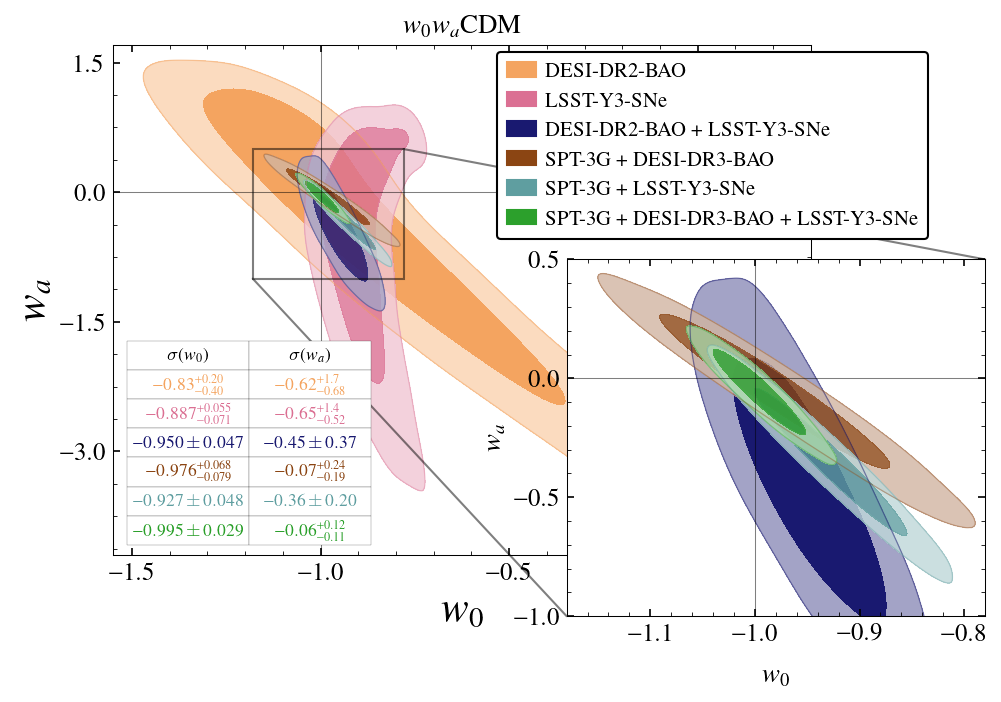

In [15]:
cosmo_iter_dic = {'w0walcdm-w_wa': ['w', 'wa']}
cosmo_name_and_tag = 'w0walcdm-w_wa'
cosmo_name, param_tags = cosmo_name_and_tag.split('-')
chain_search_str = '%s/*-%s' %(chain_fd, cosmo_name)
#print(chain_search_str)
chain_fdlist = sorted( glob.glob( chain_search_str ) )
params_to_plot = cosmo_iter_dic[cosmo_name_and_tag]

#print( 'Cosmo = %s' %(cosmo_name) )
print( 'Searchstr = %s: Total chains to analyse = %s' %(chain_search_str, len(chain_fdlist)) )
##sys.exit()

if (1):
    samples_dic = {}
    for curr_chain_fd in chain_fdlist:
        if curr_chain_fd.find('so_')>-1: continue
        if curr_chain_fd.find('s4_wide')>-1: continue            
        chainname = curr_chain_fd.split('/')[-1]
        ignore = True
        if chainname.find('lsst') == 0: 
            ignore = False
        elif chainname.find('desi') == 0: 
            ignore = False
        elif chainname.find('dr3')>-1: 
            ignore = False
        else:
            if len( chainname.split('+') ) not in [1, 2, 3]: 
            #if len( chainname.split('+') ) not in [1, 2]: #for S4 
                ignore = True
            else:
                ignore = False

        '''
        if chainname.find('lsst')>-1: ignore = True #remove me after S4
        '''

        if ignore:
            continue
        ###print(chainname, fname)
        fname = '%s/%s' %(curr_chain_fd, chainname)

        chainfile = '%s.1.txt' %(fname)
        if not os.path.exists( chainfile ): continue

        curr_samples = getdist.mcsamples.loadMCSamples( fname )
        curr_samples.removeBurn(burn_in_fraction)
        samples_dic[chainname] = curr_samples
        #print( chainname, curr_samples.samples.shape )

    print(' Chains read'); ###sys.exit()
    #contour_colors = ['sandybrown', 'tab:red', 'tab:purple', 'tab:green', 'steelblue', 'tab:red', 'black']    

array_of_samples_to_plot = []
array_of_params_or_pairs_to_plot = []
array_of_labels = []
array_of_color_arr = []
array_of_param_limits_dic = []
for pliter in range(2):
    curr_param_limits_dic = {}
    if pliter == 0:
        curr_param_limits_dic['w'] = [-1.55, 0.3]
        curr_param_limits_dic['wa'] = [-4.2, 1.7] 
        chains_to_plot = [
                          'desidr2bao_mock-%s' %(cosmo_name), 
                          'lssty3_sne_mock-%s' %(cosmo_name),
                          'desidr2bao_mock+lssty3_sne_mock-%s' %(cosmo_name),
                        'spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock-%s' %(cosmo_name),
                        'spt3g-TTEETEPP+lssty3_sne_mock-%s' %(cosmo_name),
                        'spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-%s' %(cosmo_name),
#                               'spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock-%s' %(cosmo_name),
#                               'spt3g-TTEETEPP+lssty3_sne_mock-%s' %(cosmo_name),
#                               'spt3g-TTEETEPP+desidr2bao_mock+lssty3_sne_mock-%s' %(cosmo_name),
                        ]
        color_arr = ['sandybrown', 'palevioletred', 'midnightblue', 'saddlebrown', 'cadetblue', 'tab:green']
    elif pliter == 1:
        curr_param_limits_dic['w'] = [-1.18, -0.78]#[-1.2, -0.75]
        curr_param_limits_dic['wa'] = [-1., 0.5]#0.6]    
        chains_to_plot = [
                        #'spt3g-TTEETEPP-%s' %(cosmo_name),
                        'spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock-%s' %(cosmo_name),
                        'spt3g-TTEETEPP+lssty3_sne_mock-%s' %(cosmo_name),
                        'spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-%s' %(cosmo_name),
                        ]
        color_arr = ['darkslategray', 'peru', 'tab:green']
        #color_arr = ['slateblue', 'peru', 'tab:green']
    params_to_plot = ['w', 'wa']
    samples_to_plot, labels_arr = [], []
    for chainname in chains_to_plot:
        #print(chainname in chains_to_plot)
        samples_to_plot.append( samples_dic[chainname] )
        chain_label = misc_getdist.get_chain_label(chainname)
        chain_label = chain_label.replace('-TTEETEPP', '')
        chain_label = chain_label.replace('+', ' + ')
        tmpsplit = chain_label.split('+')

        if len(tmpsplit) == 1:
            chain_label = tmpsplit[0]
        elif len(tmpsplit) == 2:
            #chain_label = tmpsplit[0] + '+' + '\n' + tmpsplit[1]
            chain_label = tmpsplit[0] + '+' + tmpsplit[1]
        elif len(tmpsplit) == 3:
            #labval = tmpsplit[0] + '+' + '\n' + tmpsplit[1] + '+' + '\n' + tmpsplit[2]
            #chain_label = tmpsplit[0] + '+' + '\n' + tmpsplit[1] + '+' + '\n' + tmpsplit[2]
            #chain_label = tmpsplit[0] + '+' + tmpsplit[1] + '+' + '\n' + tmpsplit[2]
            chain_label = tmpsplit[0] + '+' + tmpsplit[1] + '+' + tmpsplit[2]

        labels_arr.append( chain_label )    

    if (0): #write FoM    
        params_for_fom = ['w', 'wa']
        for curr_lab, curr_samples in zip( labels_arr, samples_to_plot ):
            cov_mat = misc_getdist.get_param_cov_mat_from_getdist(curr_samples, params_for_fom)
            fom = 1/np.sqrt( np.linalg.det(cov_mat) )
            print( curr_lab, fom )
        #sys.exit()
    
    array_of_samples_to_plot.append( samples_to_plot )
    array_of_params_or_pairs_to_plot.append( params_to_plot )
    array_of_labels.append( labels_arr )
    array_of_color_arr.append( color_arr )
    array_of_param_limits_dic.append( curr_param_limits_dic )
    

#array_of_zoom = [[.65, -0.21, 0.7, 0.8]]
array_of_zoom = [[.65, -0.12, 0.6, 0.7]]
array_of_param_limits_dic_for_zoom = [array_of_param_limits_dic[1]]
array_of_samples_to_plot = array_of_samples_to_plot[:1]
array_of_params_or_pairs_to_plot = array_of_params_or_pairs_to_plot[:1]
array_of_param_limits_dic = array_of_param_limits_dic[:1]
array_of_labels = array_of_labels[:1]
array_of_table_locs = [ [0.02, 0.02], [0.02, 0.02] ]
array_of_table_width = [[0.35, 0.4], [0.35, 0.3]]
array_of_table_col_width = [[0.5, 0.5], [0.5, 0.5]]
array_to_table_fontsize = [8.5, 10]
array_of_sampleinds_for_zoom = [ [2,3,4,5], False]
array_of_leglocs = [(0.55, 0.62), 1]
array_of_legfsval = [12, 10]
clf()
figsize = 3.
fsval = 13
cosmo_label = misc_getdist.get_cosmo_label( cosmo_name )
print(cosmo_name, cosmo_label)
g = misc_getdist.make_getdist_plot('multiple_2d_col',
                                   samples_to_plot, params_to_plot, 
                                   param_dict = param_dict, 
                                   param_limits_dic = array_of_param_limits_dic[0],
                                   array_of_samples_to_plot = array_of_samples_to_plot,
                                   array_of_params_or_pairs_to_plot = array_of_params_or_pairs_to_plot,
                                   array_of_labels = array_of_labels,
                                    array_of_leglocs = array_of_leglocs,
                                    array_of_legfsval = np.asarray(array_of_legfsval)-1.,
                                   array_of_color_arr = array_of_color_arr, 
                                   array_of_titles = [cosmo_label, None],
                                   array_of_param_limits_dic = array_of_param_limits_dic,
                                   array_of_zoom = array_of_zoom,  
                                   array_of_sampleinds_for_zoom = array_of_sampleinds_for_zoom, 
                                   array_of_param_limits_dic_for_zoom = array_of_param_limits_dic_for_zoom,
                                    array_of_table_locs = array_of_table_locs,
                                    array_of_table_width = array_of_table_width, 
                                    array_of_table_col_width = array_of_table_col_width,
                                    array_to_table_fontsize = array_to_table_fontsize,
                                   figsize = figsize, fsval = fsval,
                                   labels = labels_arr, 
                                   num_plot_contours = 2, filled = False,
                                   array_of_filled_arr = [[True, True, True, True, True, True], True],
                                   #array_of_num_plot_contours = [2, 2],
                                   legcol = [1,1,2],
#                                    wspace = wspace, yvisibility = yvisibility, 
#                                   cosmo_label = cosmo_label, 
#                                    xyloc_for_leg = xyloc_for_leg,
                                   show_table = True, 
                                   )
plname = '%s/%s.pdf' %(pl_folder, cosmo_name_and_tag)
#plname = '%s/png/%s.png' %(pl_folder, cosmo_name_and_tag)
#plname = '%s/png/tmp/4.png' %(pl_folder)
savefig(plname, dpi = 200.)
show()        


In [36]:
array_of_param_limits_dic

[{'w': [-1.2, -0.75], 'wa': [-1.0, 0.6]}]

In [14]:
array_of_params_or_pairs_to_plot

[[['w', 'wa']]]

chains/for_paper//*-w0walcdm
Cosmo = w0walcdm
	Total chains to analyse = 42

desidr2bao_mock+lssty3_sne_mock-w0walcdm (65240, 23)
desidr2bao_mock-w0walcdm (103992, 21)
desidr3bao_highz_mock-w0walcdm (9814, 21)
desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-w0walcdm (22461, 24)
desidr3bao_lowz_mock+desidr3bao_highz_mock-w0walcdm (256704, 22)
desidr3bao_lowz_mock-w0walcdm (70846, 21)
lssty3_sne_mock-w0walcdm (92960, 21)
lssty3_sne_mock_binned-w0walcdm (5273, 11)
spt3g-TTEETEPP+desidr2bao_mock+lssty3_sne_mock-w0walcdm (18840, 32)
spt3g-TTEETEPP+desidr2bao_mock-w0walcdm (19555, 30)
spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-w0walcdm (32928, 33)
spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock-w0walcdm (27832, 31)
spt3g-TTEETEPP+lssty3_sne_mock-w0walcdm (44296, 30)
spt3g-TTEETEPP-w0walcdm (6792, 28)
 Chains read

DESI-DR2-BAO 7.984619117756539
LSST-Y3-SNe 15.045217145667612
DESI-DR2-BAO  +  LSST-Y3-SNe 100.25792344116375


<Figure size 900x600 with 0 Axes>

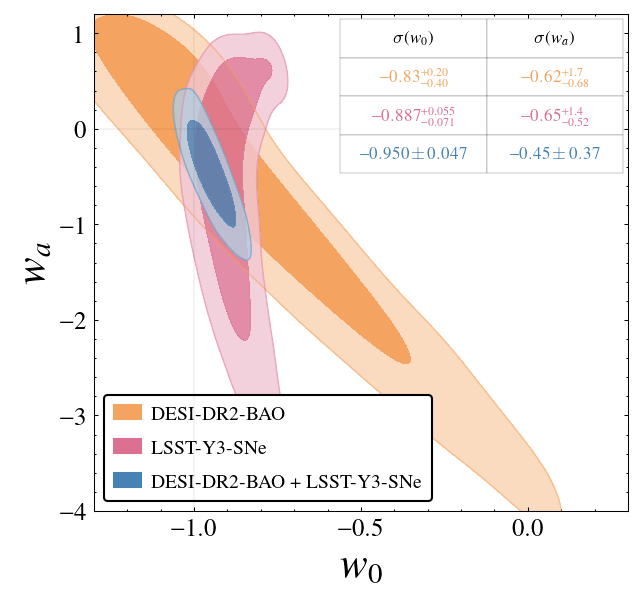

SPT-3G  +  DESI-DR3-BAO 242.59869845952142
SPT-3G  +  LSST-Y3-SNe 406.9906206066228
SPT-3G  +  DESI-DR3-BAO  +
  LSST-Y3-SNe 867.4663700664685


<Figure size 900x600 with 0 Axes>

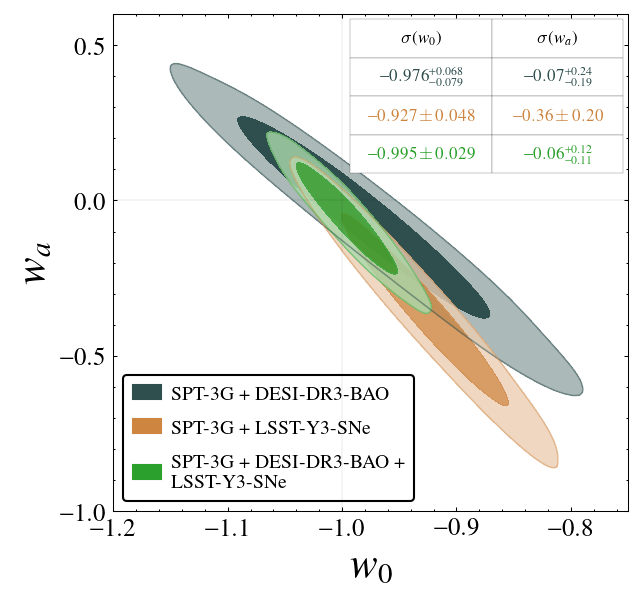

In [21]:
cosmo_iter_dic = {'w0walcdm-w_wa': ['w', 'wa']}
for cosmo_name_and_tag in cosmo_iter_dic: 
    cosmo_name, param_tags = cosmo_name_and_tag.split('-')
    chain_search_str = '%s/*-%s' %(chain_fd, cosmo_name)
    print(chain_search_str)
    chain_fdlist = sorted( glob.glob( chain_search_str ) )
    params_to_plot = cosmo_iter_dic[cosmo_name_and_tag]

    print( 'Cosmo = %s' %(cosmo_name) )
    print( '\tTotal chains to analyse = %s\n' %(len(chain_fdlist)) )
    ##sys.exit()

    samples_dic = {}
    for curr_chain_fd in chain_fdlist:
        if curr_chain_fd.find('so_')>-1: continue
        if curr_chain_fd.find('s4_wide')>-1: continue            
        chainname = curr_chain_fd.split('/')[-1]
        ignore = True
        if chainname.find('lsst') == 0: 
            ignore = False
        elif chainname.find('desi') == 0: 
            ignore = False
        elif chainname.find('dr3')>-1: 
            ignore = False
        else:
            if len( chainname.split('+') ) not in [1, 2, 3]: 
            #if len( chainname.split('+') ) not in [1, 2]: #for S4 
                ignore = True
            else:
                ignore = False
        
        '''
        if chainname.find('lsst')>-1: ignore = True #remove me after S4
        '''
                
        if ignore:
            continue
        ###print(chainname, fname)
        fname = '%s/%s' %(curr_chain_fd, chainname)

        chainfile = '%s.1.txt' %(fname)
        if not os.path.exists( chainfile ): continue

        curr_samples = getdist.mcsamples.loadMCSamples( fname )
        curr_samples.removeBurn(burn_in_fraction)
        samples_dic[chainname] = curr_samples
        print( chainname, curr_samples.samples.shape )

    print(' Chains read\n'); ###sys.exit()
    #contour_colors = ['sandybrown', 'tab:red', 'tab:purple', 'tab:green', 'steelblue', 'tab:red', 'black']    

    curr_param_limits_dic = {}
    for pliter in range(2):
        if pliter == 0:
            curr_param_limits_dic['w'] = [-1.3, 0.3]
            curr_param_limits_dic['wa'] = [-4., 1.2] 
            chains_to_plot = [
                              'desidr2bao_mock-%s' %(cosmo_name), 
                              'lssty3_sne_mock-%s' %(cosmo_name),
                              'desidr2bao_mock+lssty3_sne_mock-%s' %(cosmo_name),
#                               'spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock-%s' %(cosmo_name),
#                               'spt3g-TTEETEPP+lssty3_sne_mock-%s' %(cosmo_name),
#                               'spt3g-TTEETEPP+desidr2bao_mock+lssty3_sne_mock-%s' %(cosmo_name),
                            ]
            color_arr = ['sandybrown', 'palevioletred', 'steelblue', 'goldenrod', 'purple', 'tab:green']
        elif pliter == 1:
            curr_param_limits_dic['w'] = [-1.2, -0.75]
            curr_param_limits_dic['wa'] = [-1., 0.6]    
            chains_to_plot = [
                            #'spt3g-TTEETEPP-%s' %(cosmo_name),
                            'spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock-%s' %(cosmo_name),
                            'spt3g-TTEETEPP+lssty3_sne_mock-%s' %(cosmo_name),
                            'spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-%s' %(cosmo_name),
                            ]
            color_arr = ['darkslategray', 'peru', 'tab:green']
            #color_arr = ['slateblue', 'peru', 'tab:green']
        params_to_plot = [['w', 'wa']]
        samples_to_plot, labels_arr = [], []
        for chainname in chains_to_plot:
            #print(chainname in chains_to_plot)
            samples_to_plot.append( samples_dic[chainname] )
            chain_label = misc_getdist.get_chain_label(chainname)
            chain_label = chain_label.replace('-TTEETEPP', '')
            chain_label = chain_label.replace('+', ' + ')
            tmpsplit = chain_label.split('+')

            if len(tmpsplit) == 1:
                chain_label = tmpsplit[0]
            elif len(tmpsplit) == 2:
                #chain_label = tmpsplit[0] + '+' + '\n' + tmpsplit[1]
                chain_label = tmpsplit[0] + '+' + tmpsplit[1]
            elif len(tmpsplit) == 3:
                #labval = tmpsplit[0] + '+' + '\n' + tmpsplit[1] + '+' + '\n' + tmpsplit[2]
                #chain_label = tmpsplit[0] + '+' + '\n' + tmpsplit[1] + '+' + '\n' + tmpsplit[2]
                chain_label = tmpsplit[0] + '+' + tmpsplit[1] + '+' + '\n' + tmpsplit[2]

            labels_arr.append( chain_label )    

        #write FoM    
        params_for_fom = ['w', 'wa']
        for curr_lab, curr_samples in zip( labels_arr, samples_to_plot ):
            cov_mat = misc_getdist.get_param_cov_mat_from_getdist(curr_samples, params_for_fom)
            fom = 1/np.sqrt( np.linalg.det(cov_mat) )
            print( curr_lab, fom )
        #sys.exit()

        clf()
        g = misc_getdist.make_getdist_plot('plots_2d',
                                           samples_to_plot, 
                                           params_to_plot, 
                                           param_dict = param_dict, 
                                           param_limits_dic = curr_param_limits_dic,
                                           color_arr = color_arr, 
                                           figsize = 4.3, fsval = 12, legfsval = 9.5,# 11,
                                           labels = labels_arr, legloc = 'lower left', legcol = 4,
                                           scaling = True,#, wspace = 0.05
                                           xyloc_for_leg = [0.68, 0.95], 
                                           filled = [True, True, True],
                                           #linestyle = '-.',
                                          )
        curr_ax = g.get_axes()
        xlabval = curr_ax.get_xlabel()
        curr_ax.set_xlabel( xlabval, fontsize = 20)    
        ylabval = curr_ax.get_ylabel()
        curr_ax.set_ylabel( ylabval, fontsize = 20)    
        constraints_dic, constraints_table, colors_table, col_labels = misc_getdist.get_constraints_table(params_to_plot[0], samples_to_plot, color_arr)
        curr_table_locs = 0.46, 0.68
        curr_table_width = 0.53, 0.31
        curr_table_col_width = [0.52, 0.48]
        curr_table_fontsize = 8.2
        tx, ty = curr_table_locs
        tab_width, tab_height = curr_table_width
        table = curr_ax.table(cellText=constraints_table, 
                        colLabels=col_labels, cellLoc = 'center', 
                        bbox = (tx, ty, tab_width, tab_height), 
                        #cellColours = colors_table, 
                        colWidths = curr_table_col_width, 
                        alpha = 1., 
                        #zorder = 100.,
                        #edges = 'BT',
                        )
        # Disable auto font size
        table.auto_set_font_size(False)
        table.set_zorder(100)

        # Set the font size
        table.set_fontsize(curr_table_fontsize)
        table.set_zorder(100)

        for cellkey in table.get_celld():
            table[cellkey].set_linewidth(0.1)
            if cellkey[0] == 0: continue #header
            colorval = colors_table[cellkey[0]-1, 0]
            #print(cellkey, colorval, table[cellkey].get_text())
            table[cellkey].get_text().set_color(colorval)

        plname = '%s/%s_desi_lsst_cmb_combinations_for_spt_iter%s.pdf' %(pl_folder, cosmo_name_and_tag, pliter)

        ##savefig(plname, dpi = 200.)
        show()

# Parameter constraints for different cosmology

chains/for_paper//*-mnulcdm
Cosmo = mnulcdm
	Total chains to analyse = 42

advanced_so_baseline-TTEETE-mnulcdm (15693, 31)
advanced_so_baseline-TTEETEPP+desidr2bao_mock-mnulcdm (18555, 33)
advanced_so_baseline-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-mnulcdm (34130, 36)
advanced_so_baseline-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock-mnulcdm (31935, 34)
advanced_so_baseline-TTEETEPP+lssty3_sne_mock-mnulcdm (68096, 33)
advanced_so_baseline-TTEETEPP-mnulcdm (10704, 31)
advanced_so_goal-TTEETE-mnulcdm (12716, 31)
advanced_so_goal-TTEETEPP+desidr2bao_mock-mnulcdm (11945, 33)
advanced_so_goal-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-mnulcdm (34746, 36)
advanced_so_goal-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock-mnulcdm (35485, 34)
advanced_so_goal-TTEETEPP+lssty3_sne_mock-mnulcdm (86184, 33)
advanced_so_goal-TTEETEPP-mnulcdm (18006, 31)
desidr2bao_mock+lssty3_sne_mock-mnulcdm (48440, 22)
desidr2bao_mock-mnulcdm (47712, 2

<Figure size 900x600 with 0 Axes>

<Figure size 675x506.25 with 0 Axes>

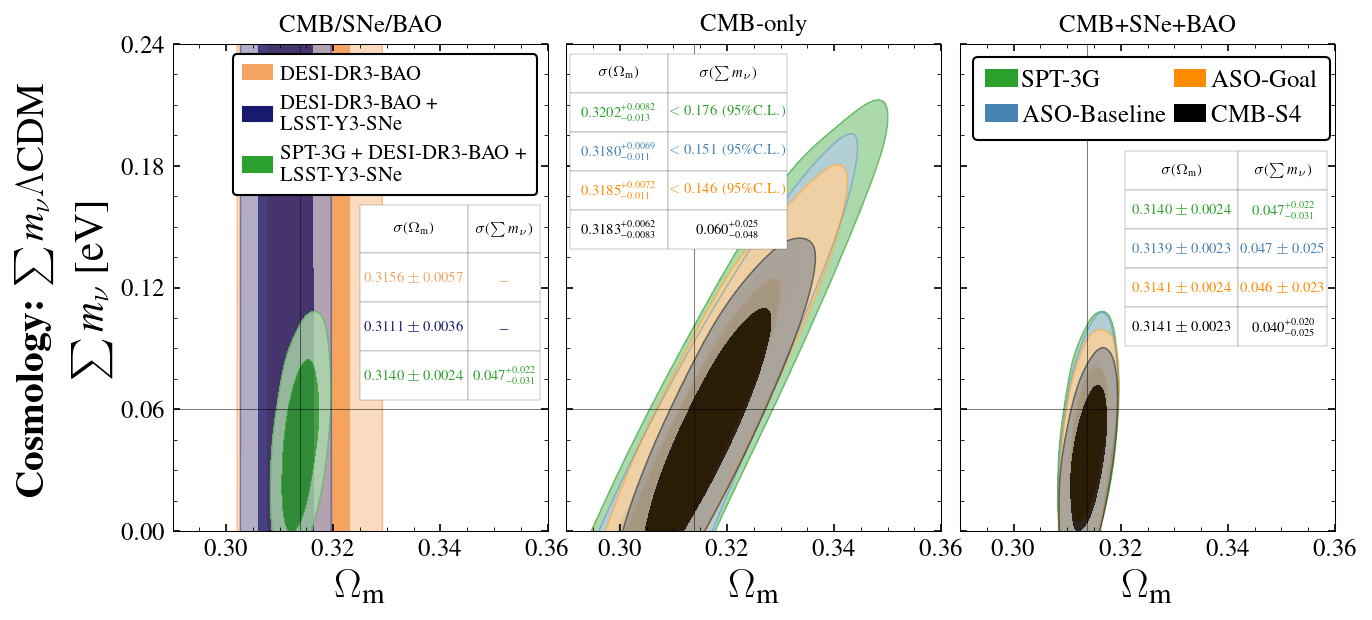

In [17]:
import copy
#chain_fd = 'chains/for_paper/20250610_bpwfnonzerooutsideellranges/'
chain_fd = 'chains/for_paper/'
param_limits_dic = {'omegam': [0.29, 0.36], 
                    'w': [-1.3, 0.3], 
                    'wa': [-4., 1.2], 
                    'mnu': [0., 0.24], 
                    'nnu': [2.8, 3.4], 
                    'H0': [65., 70.], 
                   }

cosmo_iter_dic = {
                  'mnulcdm-omegam_mnu': ['omegam', 'mnu'],  
#                 'mnulcdm-h0_mnu': ['H0', 'mnu'],  

###                    'w0walcdm-w_wa': ['w', 'wa'], 
#                    'w0waomklcdm-w_wa': ['w', 'wa'], 
#                    'w0wamnulcdm-w_wa': ['w', 'wa'],  
#                   'w0wamnulcdm-w_mnu': ['w', 'mnu'],  
#                   'w0wamnulcdm-omegam_mnu': ['omegam', 'mnu'],  
                 
#                   'w0wamnulcdm-w_mnu': ['w', 'mnu'],  
#                   'neffmnulcdm-omegam_mnu': ['omegam', 'mnu'],  
#                       'neffmnulcdm-nnu_mnu': ['nnu', 'mnu'],  
#                       'nefflcdm-nnu_H0': ['nnu', 'H0'],  
                  }

for cosmo_name_and_tag in cosmo_iter_dic: 
    cosmo_name, param_tags = cosmo_name_and_tag.split('-')
    chain_search_str = '%s/*-%s' %(chain_fd, cosmo_name)
    print(chain_search_str)
    chain_fdlist = sorted( glob.glob( chain_search_str ) )
    params_to_plot = cosmo_iter_dic[cosmo_name_and_tag]

    print( 'Cosmo = %s' %(cosmo_name) )
    print( '\tTotal chains to analyse = %s\n' %(len(chain_fdlist)) )
    ##sys.exit()

    samples_dic = {}
    for curr_chain_fd in chain_fdlist:
        chainname = curr_chain_fd.split('/')[-1]
        ignore = True
        if chainname.find('lsst') == 0: 
            ignore = False
        elif chainname.find('desi') == 0: 
            ignore = False
        elif chainname.find('dr3')>-1: 
            ignore = False
        else:
            #if len( chainname.split('+') ) not in [1, 3]: 
            if len( chainname.split('+') ) not in [1, 2]: #for S4 
                ignore = True
            else:
                ignore = False
        
        '''
        if chainname.find('lsst')>-1: ignore = True #remove me after S4
        '''
                
        if ignore:
            continue
        ###print(chainname, fname)
        fname = '%s/%s' %(curr_chain_fd, chainname)

        chainfile = '%s.1.txt' %(fname)
        if not os.path.exists( chainfile ): continue

        curr_samples = getdist.mcsamples.loadMCSamples( fname )
        curr_samples.removeBurn(burn_in_fraction)
        samples_dic[chainname] = curr_samples
        print( chainname, curr_samples.samples.shape )

    print(' Chains read\n'); ###sys.exit()
    #contour_colors = ['sandybrown', 'tab:red', 'tab:purple', 'tab:green', 'steelblue', 'tab:red', 'black']    

    #------
    chains_to_plot1 = [
                      'desidr2bao_mock-%s' %(cosmo_name), 
                      ###'spt3g-TTEETEPP+desidr2bao_mock-%s' %(cosmo_name),
                      'lssty3_sne_mock-%s' %(cosmo_name),
                      ###'spt3g-TTEETEPP+lssty3_sne_mock-%s' %(cosmo_name),
                     ##'so_baseline-TTEETEPP-w0walcdm', 
                     'desidr2bao_mock+lssty3_sne_mock-%s' %(cosmo_name),
                     #'so_baseline-TTEETE-%s' %(cosmo_name),
                     #'so_baseline-TTEETEPP+desidr2bao_mock+lssty3_sne_mock-%s' %(cosmo_name),

                      'spt3g-TTEETEPP+desidr2bao_mock+lssty3_sne_mock-%s' %(cosmo_name),
                      ##'spt3gplus-TTEETEPP+desidr2bao_mock+lssty3_sne_mock-%s' %(cosmo_name),
#                       'so_baseline-TTEETEPP+desidr2bao_mock+lssty3_sne_mock-%s' %(cosmo_name),
#                       'so_goal-TTEETEPP+desidr2bao_mock+lssty3_sne_mock-%s' %(cosmo_name),
#                       's4_wide-TTEETEPP+desidr2bao_mock+lssty3_sne_mock-%s' %(cosmo_name),

    ]
    
    '''
    if (1): #remove LSST for S4: #remove me after S4
        chains_to_plot1_ref = []
        for chainname in chains_to_plot1:
            chainname_ref = chainname.replace('+lssty3_sne_mock', '')
            chains_to_plot1_ref.append( chainname_ref )
        chains_to_plot1 = chains_to_plot1_ref
    '''
    if cosmo_name in ['mnulcdm', 'w0wamnulcdm']: #do not plot SNe for mnu cosmology.
        chains_to_plot1.remove( chains_to_plot1[1] )
    
    if cosmo_name in ['neffmnulcdm', 'nefflcdm']: #do not plot SNe for mnu cosmology.
        chains_to_plot1 = [None]
    
    if (1): #replace DESI-DR2 with DESI-DR3

        chains_to_plot_ref = []
        for c in chains_to_plot1:
            c_mod = c.replace('desidr2bao_mock', 'desidr3bao_lowz_mock+desidr3bao_highz_mock')
            chains_to_plot_ref.append( c_mod )
        chains_to_plot1 = chains_to_plot_ref
        print(chains_to_plot1); ##sys.exit()


    samples_to_plot1, labels_arr1 = [], []
    for chainname in chains_to_plot1:
        if chainname is None: continue
        samples_to_plot1.append( samples_dic[chainname] )
        chain_label = misc_getdist.get_chain_label(chainname)
        #chain_label = chain_label.replace('TTEETEPP', r'\texttt{TT/EE/TE/$\phi\phi$}')
        chain_label = chain_label.replace('-TTEETEPP', '')
        chain_label = chain_label.replace('+', ' + ')
        tmpsplit = chain_label.split('+')
        if len(tmpsplit) == 1:
            chain_label = tmpsplit[0]
        elif len(tmpsplit) == 2:
            chain_label = tmpsplit[0] + '+' + '\n' + tmpsplit[1]
            #chain_label = tmpsplit[0] + tmpsplit[1]
        elif len(tmpsplit) == 3:
            #labval = tmpsplit[0] + '+' + '\n' + tmpsplit[1] + '+' + '\n' + tmpsplit[2]
            #chain_label = tmpsplit[0] + '+' + '\n' + tmpsplit[1] + '+' + '\n' + tmpsplit[2]
            chain_label = tmpsplit[0] + '+' + tmpsplit[1] + '+' + '\n' + tmpsplit[2]
        labels_arr1.append( chain_label )    


    #------
    #------
    if cosmo_name in ['mnulcdm', 'w0wamnulcdm', 'neffmnulcdm']:
        chains_to_plot2 = [
                          'spt3g-TTEETEPP-%s' %(cosmo_name),
#                           'spt3gplus-TTEETEPP-%s' %(cosmo_name),
#                           'so_baseline-TTEETEPP-%s' %(cosmo_name),
#                           'so_goal-TTEETEPP-%s' %(cosmo_name),
                          'advanced_so_baseline-TTEETEPP-%s' %(cosmo_name),
                          'advanced_so_goal-TTEETEPP-%s' %(cosmo_name),
                          's4_wide-TTEETEPP-%s' %(cosmo_name),

        ]
        if cosmo_name == 'w0wamnulcdm': #do not yet have the chains for other exps. Only spt is available at the moment.
            chains_to_plot2 = [
                              'spt3g-TTEETEPP-%s' %(cosmo_name),
#                               'spt3gplus-TTEETEPP-%s' %(cosmo_name),
#                               'so_baseline-TTEETEPP-%s' %(cosmo_name),
#                               'so_goal-TTEETEPP-%s' %(cosmo_name),
                              'advanced_so_baseline-TTEETEPP-%s' %(cosmo_name),
                              'advanced_so_goal-TTEETEPP-%s' %(cosmo_name),
                              's4_wide-TTEETEPP-%s' %(cosmo_name),

            ]
        samples_to_plot2, labels_arr2 = [], []
        for chainname in chains_to_plot2:
            curr_samples = samples_dic[chainname]
            if (0):#cosmo_name == 'mnulcdm':
                print(chainname, curr_samples.getLatex('mnu')); ###sys.exit()
            if (0):##cosmo_name == 'mnulcdm':
                ###print(chainname, curr_samples.getLatex('mnu')); #sys.exit()
                new_samples = curr_samples.copy() # make a copy so don't change the original
                new_loglike = (curr_samples['tau']-0.056)**2/0.002**2/2
                # code currently assumes existing loglikes are set, set to zero here
                new_samples.loglikes = np.zeros(curr_samples.numrows) 
                # re-weight to account for the new likelihood
                new_samples.reweightAddingLogLikes(new_loglike)             
                curr_samples = new_samples.copy()

            samples_to_plot2.append( curr_samples )
            chain_label = misc_getdist.get_chain_label(chainname)
            chain_label = chain_label.split('-TT')[0]
            #chain_label = chain_label.replace('TTEETEPP', r'\texttt{TT/EE/TE/$\phi\phi$}')
            #chain_label = chain_label.replace('+', ' + ')
            labels_arr2.append( chain_label )    

    #------
    #------
    chains_to_plot3 = [
                      'spt3g-TTEETEPP+desidr2bao_mock+lssty3_sne_mock-%s' %(cosmo_name),
#                       'spt3gplus-TTEETEPP+desidr2bao_mock+lssty3_sne_mock-%s' %(cosmo_name),
#                       'so_baseline-TTEETEPP+desidr2bao_mock+lssty3_sne_mock-%s' %(cosmo_name),
#                       'so_goal-TTEETEPP+desidr2bao_mock+lssty3_sne_mock-%s' %(cosmo_name),
                      'advanced_so_baseline-TTEETEPP+desidr2bao_mock+lssty3_sne_mock-%s' %(cosmo_name),
                      'advanced_so_goal-TTEETEPP+desidr2bao_mock+lssty3_sne_mock-%s' %(cosmo_name),
                      's4_wide-TTEETEPP+desidr2bao_mock+lssty3_sne_mock-%s' %(cosmo_name),
    ]
    
    if (1): #replace DESI-DR2 with DESI-DR3

        chains_to_plot_ref = []
        for c in chains_to_plot3:
            c_mod = c.replace('desidr2bao_mock', 'desidr3bao_lowz_mock+desidr3bao_highz_mock')
            chains_to_plot_ref.append( c_mod )
        chains_to_plot3 = chains_to_plot_ref
        print(chains_to_plot3); ##sys.exit()
        
    
    '''
    if (1): #remove LSST for S4: #remove me after S4
        chains_to_plot3_ref = []
        for chainname in chains_to_plot3:
            chainname_ref = chainname.replace('+lssty3_sne_mock', '')
            chains_to_plot3_ref.append( chainname_ref )
        chains_to_plot3 = chains_to_plot3_ref
    '''
    
    samples_to_plot3, labels_arr3 = [], []
    for chainname in chains_to_plot3:
        curr_samples = samples_dic[chainname]
        if (0):#cosmo_name in ['mnulcdm', 'w0wamnulcdm', 'neffmnulcdm']:
            print(chainname, curr_samples.getLatex('mnu')); ###sys.exit()
        if (0):##cosmo_name == 'mnulcdm':
            new_samples = curr_samples.copy() # make a copy so don't change the original
            new_loglike = (curr_samples['tau']-0.056)**2/0.002**2/2
            # code currently assumes existing loglikes are set, set to zero here
            new_samples.loglikes = np.zeros(curr_samples.numrows) 
            # re-weight to account for the new likelihood
            new_samples.reweightAddingLogLikes(new_loglike)             
            curr_samples = new_samples.copy()
            print(chainname, curr_samples.getLatex('mnu')); ###sys.exit()
        
        samples_to_plot3.append( curr_samples )
        chain_label = misc_getdist.get_chain_label(chainname)
        chain_label = chain_label.split('-TT')[0]
        #chain_label = chain_label.replace('TTEETEPP', r'\texttt{TT/EE/TE/$\phi\phi$}')
        #chain_label = chain_label.replace('+', ' + ')
        labels_arr3.append( chain_label )    
    #------
    #------

    if cosmo_name in ['mnulcdm', 'w0wamnulcdm', 'neffmnulcdm']:
        if len(samples_to_plot1) == 3:
            color_arr1 = ['sandybrown', 'midnightblue', 'tab:green']
        elif len(samples_to_plot1) == 4:
            color_arr1 = ['sandybrown', 'midnightblue', 'tab:green', 'black']
        elif len(samples_to_plot1) == 5:
            color_arr1 = ['sandybrown', 'tab:pink', 'midnightblue', 'darkred', 'tab:green']
        elif len(samples_to_plot1) == 6:
            color_arr1 = ['sandybrown', 'sandybrown', 'tab:pink', 'tab:pink', 'midnightblue', 'tab:green']
    else:
        if len(samples_to_plot1) == 4:
            color_arr1 = ['sandybrown', 'palevioletred', 'steelblue', 'tab:green']
        elif len(samples_to_plot1) == 5:
            color_arr1 = ['sandybrown', 'tab:pink', 'steelblue', 'darkred', 'tab:green']
        elif len(samples_to_plot1) == 6:
            color_arr1 = ['sandybrown', 'darkred', 'lightpink', 'deeppink', 'steelblue', 'tab:green']
    #color_arr2 = ['tab:green', 'black', 'steelblue', 'darkorange', 'black']
    color_arr2 = ['tab:green', 'steelblue', 'darkorange', 'black']
    color_arr3 = color_arr2

    array_of_table_locs = [ [0.02, 0.02], [0.02, 0.02] ]
    array_of_table_width = [[0.35, 0.3], [0.35, 0.3]]
    array_of_table_col_width = [[0.5, 0.5], [0.5, 0.5]]
    
    array_of_param_limits_dic_for_zoom = None
    xyloc_for_leg = None
    if cosmo_name_and_tag in ['mnulcdm-omegam_mnu', 'mnulcdm-h0_mnu']:
        array_of_samples_to_plot = [samples_to_plot1, samples_to_plot2, samples_to_plot3]
        array_of_params_or_pairs_to_plot = [params_to_plot, params_to_plot, params_to_plot]
        array_of_color_arr = [color_arr1, color_arr2, color_arr3]
        array_of_filled_arr = [True, True, True]
        array_of_labels = [labels_arr1, labels_arr3, labels_arr3]
        array_of_leglocs = ['upper right', 'upper left', 'upper left']
        array_of_legfsval = [11, 14, 13]
        array_of_titles = [r'CMB/SNe/BAO', r'CMB-only', r'CMB+SNe+BAO']
        array_of_zoom = [None, None, None]
        array_of_sampleinds_for_zoom = None
        array_of_param_limits_dic = None #[param_limits_dic, param_limits_dic, param_limits_dic]
        if cosmo_name_and_tag == 'mnulcdm-omegam_mnu':
            array_of_table_locs = [ [0.5, 0.27], [0.01, 0.58], [0.44, 0.38] ]
            array_of_table_width = [[0.48, 0.4], [0.58, 0.4], [0.54, 0.4]]
            array_of_table_col_width = [[0.6, 0.4], [0.45, 0.55], [0.56, 0.44]]
        elif cosmo_name_and_tag == 'mnulcdm-h0_mnu':
            array_of_table_locs = [ [0.52, 0.27], [0.5, 0.58], [0.52, 0.27] ]
            array_of_table_width = [[0.45, 0.38], [0.47, 0.38], [0.47, 0.38]]
            array_of_table_col_width = [[0.6, 0.4], [0.55, 0.45], [0.55, 0.45]]
        array_to_table_fontsize = [7.1, 7.1, 7.1]
        
        figsize = 4.5
        wspace = 0.05
        yvisibility = False

    elif cosmo_name_and_tag in ['w0wamnulcdm-omegam_mnu']:
        array_of_samples_to_plot = [samples_to_plot1, samples_to_plot2, samples_to_plot3]
        array_of_params_or_pairs_to_plot = [params_to_plot, params_to_plot, params_to_plot]
        array_of_color_arr = [color_arr1, color_arr2, color_arr3]
        array_of_filled_arr = [True, True, True]
        array_of_labels = [labels_arr1, labels_arr3, labels_arr3]
        array_of_leglocs = ['upper right', 'upper left', 'upper right']
        array_of_legfsval = [11, 13, 12.5]
        array_of_titles = [r'CMB/SNe/BAO', r'CMB-only', r'CMB+SNe+BAO']
        array_of_zoom = [None, None, None]
        array_of_sampleinds_for_zoom = None

        curr_param_limits_dic_1 = copy.copy( param_limits_dic )
        curr_param_limits_dic_2 = copy.copy( param_limits_dic )
        curr_param_limits_dic_1['omegam'] = [0.22, 0.44]
        curr_param_limits_dic_2['omegam'] = [0.2, 0.58]
        array_of_param_limits_dic =  [curr_param_limits_dic_1, curr_param_limits_dic_2, param_limits_dic] #[param_limits_dic, param_limits_dic_zoomed]            
            
        array_of_table_locs = [ [0.52, 0.02], [0.02, 0.58], [0.52, 0.02] ]
        array_of_table_width = [[0.47, 0.4], [0.47, 0.4], [0.47, 0.4]]
        array_of_table_col_width = [[0.6, 0.4], [0.6, 0.4], [0.6, 0.4]]
        array_to_table_fontsize = [7.2, 7.2, 7.2]
            
        figsize = 4.5
        wspace = 0.05
        yvisibility = False

    elif cosmo_name_and_tag in ['w0wamnulcdm-w_mnu']:
        array_of_samples_to_plot = [samples_to_plot1, samples_to_plot3]
        array_of_params_or_pairs_to_plot = [params_to_plot, params_to_plot]
        array_of_color_arr = [color_arr1, color_arr3]
        array_of_filled_arr = [True, True]
        array_of_labels = [labels_arr1, labels_arr3]
        array_of_leglocs = ['upper right', 'upper left']
        array_of_legfsval = [11, 12.5]
        array_of_titles = [r'CMB/SNe/BAO', r'CMB+SNe+BAO']
        array_of_zoom = [None, None]
        array_of_sampleinds_for_zoom = None

        curr_param_limits_dic_1 = copy.copy( param_limits_dic )
        curr_param_limits_dic_2 = copy.copy( param_limits_dic )
        curr_param_limits_dic_1['w'] = [-1.5, 0.3]
        curr_param_limits_dic_2['w'] = [-1.15, -0.8]
        array_of_param_limits_dic =  [curr_param_limits_dic_1, curr_param_limits_dic_2] #[param_limits_dic, param_limits_dic_zoomed]            
            
        array_of_table_locs = [ [0.53, 0.02], [0.02, 0.57 ] ]
        array_of_table_width = [[0.45, 0.4], [0.45, 0.4]]
        array_of_table_col_width = [[0.6, 0.4], [0.5, 0.5]]
        array_to_table_fontsize = [8, 8.]
            
        figsize = 4.5
        wspace = 0.05
        yvisibility = False
        xyloc_for_leg = 0.75, 0.85
        
    elif cosmo_name_and_tag in ['neffmnulcdm-omegam_mnu', 'neffmnulcdm-nnu_mnu', 'nefflcdm-nnu_H0']:
        array_of_samples_to_plot = [samples_to_plot2, samples_to_plot3]
        array_of_params_or_pairs_to_plot = [params_to_plot, params_to_plot]
        array_of_color_arr = [color_arr2, color_arr3]
        array_of_filled_arr = [True, True]
        array_of_labels = [labels_arr3, None]
        array_of_leglocs = ['upper left', 'upper left']
        array_of_legfsval = [14, 13.]
        array_of_titles = [r'CMB-only', r'CMB+SNe+BAO']
        array_of_zoom = [None, None]
        array_of_param_limits_dic = None
        
        if cosmo_name_and_tag == 'nefflcdm-nnu_H0':
            array_of_table_locs = [ [0.53, 0.02], [0.55, 0.02] ]
        elif cosmo_name_and_tag == 'neffmnulcdm-nnu_mnu':
            array_of_table_locs = [ [0.02, 0.58], [0.53, 0.58] ]
        elif cosmo_name_and_tag == 'neffmnulcdm-omegam_mnu':
            array_of_table_locs = [ [0.02, 0.58], [0.53, 0.58] ]
        array_of_table_width = [[0.43, 0.38], [0.43, 0.38]]
        array_of_table_col_width = [[0.55, 0.45], [0.55, 0.45]]
        array_to_table_fontsize = [7.5, 7.5]
        
        if (1):
            xyloc_for_leg = 0.52, 0.85
            array_of_labels = [None, labels_arr3]
        figsize = 4.5
        wspace = 0.05
        yvisibility = False

    elif cosmo_name_and_tag in ['w0walcdm-w_wa', 'w0wamnulcdm-w_wa', 'w0waomklcdm-w_wa']:
        labels_arr2 = None
        array_of_samples_to_plot = [samples_to_plot1, samples_to_plot3]
        ##print(array_of_samples_to_plot); sys.exit()
        array_of_params_or_pairs_to_plot = [params_to_plot, params_to_plot]
        array_of_color_arr = [color_arr1, color_arr3]
        if len(color_arr1) == 4:
            array_of_filled_arr = [True, False]
        else:
            array_of_filled_arr = [[True, False, True, False, True, True], False]
        array_of_labels = [labels_arr1, labels_arr3]
        array_of_leglocs = ['lower right', 'upper right']
        array_of_legfsval = [11, 14]
        array_of_titles = [r'CMB/SNe/BAO', r'CMB+SNe+BAO']
        param_limits_dic_2 = {'omegam': [0.29, 0.34], 
                            'w': [-1.1, -0.85], 
                            'wa': [-0.8, 0.5], 
                            'mnu': [0., 0.24], 
                           }
        param_limits_dic_zoomed = {'omegam': [0.29, 0.34], 
                            'w': [-1.1, -0.88], 
                            'wa': [-0.6, 0.3], 
                            'mnu': [0., 0.24], 
                           }
        
        array_of_param_limits_dic = [param_limits_dic, param_limits_dic_2]
        array_of_zoom = [ [0.6,0.6,0.38,0.38], None, None]
        ###array_of_zoom = [None, None, None]
        if cosmo_name_and_tag == 'w0walcdm-w_wa':
            array_of_sampleinds_for_zoom = [ [-2, -1], False, False]
        elif cosmo_name_and_tag == 'w0wamnulcdm-w_wa':
            array_of_sampleinds_for_zoom = [ [1, 2], False, False]
        array_of_param_limits_dic_for_zoom = [ param_limits_dic_zoomed, None, None]
        array_of_table_locs = [ [0.02, 0.02], [0.02, 0.02] ]
        array_of_table_width = [[0.35, 0.3], [0.35, 0.3]]
        array_of_table_col_width = [[0.55, 0.45], [0.55, 0.45]]
        array_to_table_fontsize = [7.3, 7.3]
        
        figsize = 4.
        wspace = 0.12
        yvisibility = True
    else:
        array_of_samples_to_plot = None        
    labels_arr = labels_arr1 #np.asarray( labels_arr1 + labels_arr2 + labels_arr3 )
    samples_to_plot = array_of_samples_to_plot[0]
    
    if (0):
        array_of_labels_mod = ''
        for lab in array_of_labels:
            if lab.find('spt3gplus')>-1:
                lab_mod = lab.replace('spt3gplus', r'spt3g$+$')
            else:
                lab_mod = lab
            array_of_labels.append( lab_mod )
        
        array_of_labels = np.asarray( array_of_labels_mod )      
        
    #write FoM    
    if cosmo_name_and_tag in ['w0walcdm-w_wa', 'w0waomklcdm-w_wa', 'w0wamnulcdm-w_wa']:
        params_for_fom = ['w', 'wa']
        for tmp_labels_arr, tmp_samples_arr in zip( array_of_labels, array_of_samples_to_plot ):
            for sampleind, curr_samples in enumerate( tmp_samples_arr ):
                cov_mat = misc_getdist.get_param_cov_mat_from_getdist(curr_samples, params_for_fom)
                fom = 1/np.sqrt( np.linalg.det(cov_mat) )
                print( tmp_labels_arr[sampleind], fom )
        #sys.exit()


    clf()
    fsval = 12
    cosmo_label = misc_getdist.get_cosmo_label( cosmo_name )
    print(cosmo_name, cosmo_label)
    g = misc_getdist.make_getdist_plot('multiple_2d_col',
                                       samples_to_plot, params_to_plot, 
                                       param_dict = param_dict, 
                                       param_limits_dic = param_limits_dic,
                                       array_of_samples_to_plot = array_of_samples_to_plot,
                                       array_of_params_or_pairs_to_plot = array_of_params_or_pairs_to_plot,
                                       array_of_labels = array_of_labels,
                                       array_of_leglocs = array_of_leglocs,
                                       array_of_legfsval = np.asarray(array_of_legfsval)-1.,
                                       array_of_color_arr = array_of_color_arr, 
                                       array_of_titles = array_of_titles,
                                       array_of_param_limits_dic = array_of_param_limits_dic,
                                       array_of_zoom = array_of_zoom,  
                                       array_of_sampleinds_for_zoom = array_of_sampleinds_for_zoom, 
                                       array_of_param_limits_dic_for_zoom = array_of_param_limits_dic_for_zoom,
                                       array_of_table_locs = array_of_table_locs,
                                       array_of_table_width = array_of_table_width, 
                                       array_of_table_col_width = array_of_table_col_width,
                                       array_to_table_fontsize = array_to_table_fontsize,
                                       figsize = figsize, fsval = fsval,
                                       labels = labels_arr, 
                                       num_plot_contours = 2, filled = False,
                                       array_of_filled_arr = array_of_filled_arr,
                                       #array_of_num_plot_contours = [2, 1, 1],
                                       legcol = [1,1,2],
                                       wspace = wspace, yvisibility = yvisibility, cosmo_label = cosmo_label, 
                                       xyloc_for_leg = xyloc_for_leg,
                                       show_table = True, 
                                       )
    plname = '%s/%s.pdf' %(pl_folder, cosmo_name_and_tag)
    #plname = '%s/png/%s.png' %(pl_folder, cosmo_name_and_tag)
    #plname = '%s/png/tmp/4.png' %(pl_folder)
    savefig(plname, dpi = 200.)
    show()
    ###sys.exit()

if cosmo_name == 'w0walcdm':
    chains_to_plot = [
                    #'spt3g-TTEETEPP-%s' %(cosmo_name),
                    'spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock-%s' %(cosmo_name),
                    'spt3g-TTEETEPP+lssty3_sne_mock-%s' %(cosmo_name),
                    'spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-%s' %(cosmo_name),
                    ]
    params_to_plot = [['w', 'wa']]
    samples_to_plot, labels_arr = [], []
    color_arr = ['sandybrown', 'palevioletred', 'tab:green']
    for chainname in chains_to_plot:
        #print(chainname in chains_to_plot)
        samples_to_plot.append( samples_dic[chainname] )
        chain_label = misc_getdist.get_chain_label(chainname)
        chain_label = chain_label.replace('-TTEETEPP', '')
        chain_label = chain_label.replace('+', ' + ')
        tmpsplit = chain_label.split('+')

        if len(tmpsplit) == 1:
            chain_label = tmpsplit[0]
        elif len(tmpsplit) == 2:
            chain_label = tmpsplit[0] + '+' + '\n' + tmpsplit[1]
            #chain_label = tmpsplit[0] + tmpsplit[1]
        elif len(tmpsplit) == 3:
            #labval = tmpsplit[0] + '+' + '\n' + tmpsplit[1] + '+' + '\n' + tmpsplit[2]
            #chain_label = tmpsplit[0] + '+' + '\n' + tmpsplit[1] + '+' + '\n' + tmpsplit[2]
            chain_label = tmpsplit[0] + '+' + tmpsplit[1] + '+' + '\n' + tmpsplit[2]

        labels_arr.append( chain_label )    

    #write FoM    
    params_for_fom = ['w', 'wa']
    for curr_lab, curr_samples in zip( labels_arr, samples_to_plot ):
        cov_mat = misc_getdist.get_param_cov_mat_from_getdist(curr_samples, params_for_fom)
        fom = 1/np.sqrt( np.linalg.det(cov_mat) )
        print( curr_lab, fom )
    #sys.exit()
        
    #print( array_of_param_limits_dic_for_zoom )
    curr_param_limits_dic = {}
    curr_param_limits_dic['w'] = [-1.2, -0.75]
    curr_param_limits_dic['wa'] = [-1., 0.6]    
    #sys.exit()
    clf()
    g = misc_getdist.make_getdist_plot('plots_2d',
                                       samples_to_plot, 
                                       params_to_plot, 
                                       param_dict = param_dict, 
                                       param_limits_dic = curr_param_limits_dic,
                                       color_arr = color_arr, 
                                       figsize = 4.3, fsval = 12, legfsval = 9.5,# 11,
                                       labels = labels_arr, legloc = 'lower left', legcol = 4,
                                       scaling = True,#, wspace = 0.05
                                       xyloc_for_leg = [0.68, 0.95], 
                                       filled = [True, True, True],
                                       #linestyle = '-.',
                                      )
    curr_ax = g.get_axes()
    xlabval = curr_ax.get_xlabel()
    curr_ax.set_xlabel( xlabval, fontsize = 20)    
    ylabval = curr_ax.get_ylabel()
    curr_ax.set_ylabel( ylabval, fontsize = 20)    
    constraints_dic, constraints_table, colors_table, col_labels = misc_getdist.get_constraints_table(params_to_plot[0], samples_to_plot, color_arr)
    curr_table_locs = 0.46, 0.68
    curr_table_width = 0.53, 0.31
    curr_table_col_width = [0.52, 0.48]
    curr_table_fontsize = 8.2
    tx, ty = curr_table_locs
    tab_width, tab_height = curr_table_width
    table = curr_ax.table(cellText=constraints_table, 
                    colLabels=col_labels, cellLoc = 'center', 
                    bbox = (tx, ty, tab_width, tab_height), 
                    #cellColours = colors_table, 
                    colWidths = curr_table_col_width, 
                    alpha = 1., 
                    #zorder = 100.,
                    #edges = 'BT',
                    )
    # Disable auto font size
    table.auto_set_font_size(False)
    table.set_zorder(100)

    # Set the font size
    table.set_fontsize(curr_table_fontsize)
    table.set_zorder(100)

    for cellkey in table.get_celld():
        table[cellkey].set_linewidth(0.1)
        if cellkey[0] == 0: continue #header
        colorval = colors_table[cellkey[0]-1, 0]
        #print(cellkey, colorval, table[cellkey].get_text())
        table[cellkey].get_text().set_color(colorval)

    plname = '%s/%s_desi_lsst_cmb_combinations_for_spt.pdf' %(pl_folder, cosmo_name_and_tag)

    savefig(plname, dpi = 200.)
    show()

# w0-wa parameter whisker for different cosmologies

w0walcdm
w0walcdm
w0wamnulcdm
w0wamnulcdm
w0waomklcdm
w0waomklcdm
w0wamnuomklcdm
w0wamnuomklcdm
$\sigma / \sigma_{w_{0}  w_{a}   {\rm CDM}}^{\rm Joint}$


<Figure size 900x600 with 0 Axes>

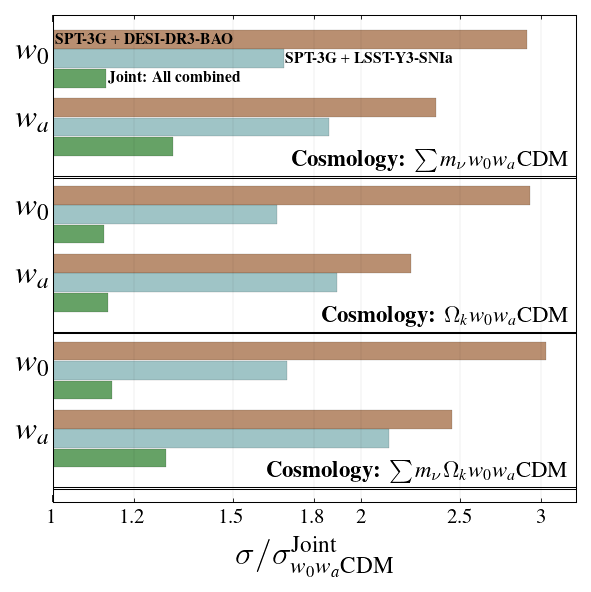

In [20]:
from matplotlib import ticker
chain_fd = 'chains/for_paper/'
cosmo_iter_dic = {
                   'w0walcdm': ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0', 'w', 'wa'], 
                   'w0wamnulcdm': ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0', 'mnu', 'w', 'wa'], 
                   'w0waomklcdm': ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0', 'omk', 'w', 'wa'], 
                   'w0wamnuomklcdm': ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0', 'omk', 'w', 'wa'], 
                  }

#for posterior
posterior_xarr_dic = {'mnu': np.arange(0., 0.25, 0.002)}
identifer_arr = [
             'TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock',
             'TTEETEPP+lssty3_sne_mock', 
             'TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock',
            ]

if (0):
    sigma_dic = {}
    fom_dic = {}
    use_cov_or_atual = 'cov'
    posterior_yarr_dic = {}
    for cosmo_name in cosmo_iter_dic:
        print( 'Cosmo = %s' %(cosmo_name) )
        params_to_plot = cosmo_iter_dic[cosmo_name]
        sigma_dic[cosmo_name] = {}
        posterior_yarr_dic[cosmo_name] = {}
        fom_dic[cosmo_name] = {}
        for identifer in identifer_arr:
            print( '  identifer = %s' %(identifer) )
            sigma_dic[cosmo_name][identifer] = {}
            posterior_yarr_dic[cosmo_name][identifer] = {}
            fom_dic[cosmo_name][identifer] = {}
            chain_search_str = '%s/spt3g*%s-%s' %(chain_fd, identifer, cosmo_name)
            #chain_search_str = '%s/[ad,s]*%s-%s' %(chain_fd, identifer, cosmo_name)
            #chain_search_str = '%s/ad*baseline*%s-%s' %(chain_fd, identifer, cosmo_name)
            chain_fdlist = sorted( glob.glob( chain_search_str ) )

            #print( '\tTotal chains to analyse = %s\n' %(len(chain_fdlist)) )
            if len( chain_fdlist ) == 0:
                print('\tnoting available for %s: %s\n' %(identifer, cosmo_name))
                continue

            cmb_exp_name_arr = []
            for curr_chain_fd in chain_fdlist:
                chainname = curr_chain_fd.split('/')[-1]
                fname = '%s/%s' %(curr_chain_fd, chainname)
                chainfile = '%s.1.txt' %(fname)
                if not os.path.exists( chainfile ): continue
                expsetname = chainname.replace('-%s' %(cosmo_name), '')
                cmb_exp_name = expsetname.split('+')[0].split('-')[0]
                cmb_exp_name_arr.append( cmb_exp_name )

                curr_samples = getdist.mcsamples.loadMCSamples( fname )
                print( '\t', chainname, curr_samples.samples.shape )
                curr_samples.removeBurn(burn_in_fraction)

                #get the fom
                if cosmo_name in ['w0wamnulcdm', 'w0walcdm']:
                    params_for_fom = ['w', 'wa']
                elif cosmo_name == 'neffmnulcdm':
                    params_for_fom = ['mnu', 'nnu']
                elif cosmo_name == 'mnulcdm':
                    params_for_fom = ['mnu']
                cov_mat = misc_getdist.get_param_cov_mat_from_getdist(curr_samples, params_for_fom)
                fom = 1/np.sqrt( np.linalg.det(cov_mat) )
                fom_dic[cosmo_name][identifer][cmb_exp_name] = fom

                #get the errros
                sigma_dic[cosmo_name][identifer][cmb_exp_name] = {}
                posterior_yarr_dic[cosmo_name][identifer][cmb_exp_name] = {}
                if use_cov_or_atual == 'actual':
                    '''
                    for pind, ppp in enumerate( params_to_plot ):
                        sigma_dic[cosmo_name][identifer][chainname][ppp] = curr_sigma_arr[pind]
                    '''
                    pass

                elif use_cov_or_atual == 'cov':
                    curr_cov_mat = misc_getdist.get_param_cov_mat_from_getdist(curr_samples, params_to_plot)
                    curr_sigma_arr = np.sqrt( np.diag( curr_cov_mat ) )
                    for pind, ppp in enumerate( params_to_plot ):
                        sigma_dic[cosmo_name][identifer][cmb_exp_name][ppp] = curr_sigma_arr[pind]

                        if ppp in posterior_xarr_dic:
                            density1d_obj = curr_samples.get1DDensity(ppp)
                            posterior = density1d_obj( posterior_xarr_dic[ppp] )
                            posterior_yarr_dic[cosmo_name][identifer][cmb_exp_name][ppp] = posterior
                            
#sys.exit()
#print(posterior_yarr_dic.keys())
#whisker plots
reqd_param_arr = ['w', 'wa']
'''
reqd_identifer_dic ={
             'TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock': r'CMB $+$' + '\n' + 'DESI-DR3-BAO',
             'TTEETEPP+lssty3_sne_mock': r'CMB $+$' + '\n' + 'LSST-Y3-SNIa', 
             'TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock': r'CMB $+$' + '\n' + 'DESI-DR3-BAO $+$' + '\n' + 'LSST-Y3-SNIa',
             }
'''
reqd_identifer_dic ={
             'TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock': r'SPT-3G $+$ DESI-DR3-BAO',
             'TTEETEPP+lssty3_sne_mock': r'SPT-3G $+$ LSST-Y3-SNIa', 
             'TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock': r'Joint: All combined',
             }

baseline_cosmo_name = 'w0walcdm'
baseline_iden = 'TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock'
pl_specs_dic = {
             'TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock': [None, 'saddlebrown'],#'/', ''],
             'TTEETEPP+lssty3_sne_mock': [None, 'cadetblue'],#'oo', None], 
             'TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock': [None, 'darkgreen'],
            }
cmb_exp_color_dic = {'advanced_so_baseline': 'steelblue', 
                 'advanced_so_goal': 'darkorange', 
                 's4_wide': 'black', 
                 'spt3g': 'darkgreen'}
#cmb_exp_name_arr_to_plot = ['spt3g', 'advanced_so_baseline', 'advanced_so_goal', 's4_wide']
cmb_exp_name_arr_to_plot = ['spt3g']
plot_dic = {}
for cosmo_name in sigma_dic:
    plot_dic[cosmo_name] = {}
    for pcntr, ppp in enumerate( reqd_param_arr ):
        #if cosmo_name == baseline_cosmo_name: continue
        print(cosmo_name)
        plot_dic[cosmo_name][ppp] = {}
        for cmb_exp_name in cmb_exp_name_arr_to_plot:
            plot_dic[cosmo_name][ppp][cmb_exp_name] = {}
            for iden in reqd_identifer_dic:
                curr_sigma = sigma_dic[cosmo_name][iden][cmb_exp_name][ppp]
                plot_dic[cosmo_name][ppp][cmb_exp_name][iden] = curr_sigma

    
#plot
loc = 0
#ax = subplot(tr, tc, pcntr+1)
bar_width_val = 0.96
sep_val = 1
#xmin, xmax = 1., 1.4#5
xmin, xmax = 1., 3.25
clf()
fsval = 14
figure(figsize = (4.5, 4.3))
#figure(figsize = (4.5, 4.))
#subplots_adjust(wspace = 0.02)
#tr, tc = 1, 2
reqd_cmb_exp_name = 'spt3g'
ax = subplot(111, xscale = 'log')
for cosmo_cntr, cosmo_name in enumerate(plot_dic): 
    if cosmo_name == baseline_cosmo_name: continue
    for pcntr, ppp in enumerate( plot_dic[cosmo_name] ):
        #write yticks
        #print(loc-0.6)
        text(xmin-0.01, loc-1, r'%s' %(misc_getdist.get_latex_param_str(ppp)), 
             fontsize = fsval+2, ha = 'right')
        for iden in plot_dic[cosmo_name][ppp][reqd_cmb_exp_name]:
            if iden not in reqd_identifer_dic: continue
            curr_hatchval, curr_colorval = pl_specs_dic[iden]
            if curr_colorval is None: 
                curr_colorval = cmb_exp_color_dic[cmb_exp_name]
            if baseline_iden is None:
                curr_baseline_val = plot_dic[baseline_cosmo_name][ppp][reqd_cmb_exp_name][iden]
            else:
                curr_baseline_val = plot_dic[baseline_cosmo_name][ppp][reqd_cmb_exp_name][baseline_iden]
            curr_val_to_plot = plot_dic[cosmo_name][ppp][reqd_cmb_exp_name][iden]
            #print(curr_baseline_val, curr_val_to_plot, cosmo_name, iden)
            curr_val_to_plot = curr_val_to_plot / curr_baseline_val
            if curr_val_to_plot <= 1.:
                print(plot_dic[cosmo_name][ppp][reqd_cmb_exp_name][iden], curr_baseline_val)
                #curr_val_to_plot = 1.02
                pass
                print(ppp, cosmo_name, iden, curr_val_to_plot)
            #print(ppp, cosmo_name, iden, curr_val_to_plot)
            if pcntr == 0 and cosmo_cntr == 1:
                labval = reqd_identifer_dic[iden]
            else:
                labval = None
            barh( loc, curr_val_to_plot, height = bar_width_val, color = curr_colorval, 
                 hatch = curr_hatchval, edgecolor = 'black', lw = 0.1, alpha = 0.6,
                label = labval)

            #write dataset
            if pcntr == 0 and cosmo_cntr == 1:## and len(cosmo_iter_dic) == 3:
                textfsval = fsval-6.5
                textcolorval = 'black' #curr_colorval
                if baseline_iden is None:
                    text(curr_val_to_plot+0.005, loc-0.2, r'{\bf %s}' %(reqd_identifer_dic[iden]), 
                         fontsize = textfsval, color = textcolorval)
                elif baseline_iden == 'TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock':
                    if curr_val_to_plot>2:
                        text(xmin+0.005, loc-0.2, r'{\bf %s}' %(reqd_identifer_dic[iden]), 
                             fontsize = textfsval, color = textcolorval)
                    else:
                        text(curr_val_to_plot+0.005, loc-0.2, r'{\bf %s}' %(reqd_identifer_dic[iden]), 
                             fontsize = textfsval, color = textcolorval)
                
                
            loc -= sep_val
        loc -= sep_val/2


    current_cosmo_label = misc_getdist.get_cosmo_label(cosmo_name)
    text(xmax-0.05, loc+0.5, r'{\bf Cosmology:} %s' %(current_cosmo_label), fontsize = fsval-3, ha = 'right')
    axhline(loc, color = 'black', lw = 0.5)
    axhline(loc-0.1, color = 'black', lw = 0.5)
    loc -= sep_val
if (0):##len(cosmo_iter_dic) > 3:
    legend(loc = 3, fontsize = 10, bbox_to_anchor = (0.02, 1.005), ncol = 2)
yticks([])
xlim(xmin, xmax)
#xlim(xmin, 2.5)
ylim(loc+0.25, 1.25)
#ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(0.2))
#ax.xaxis.set_minor_locator(ticker.LogLocator(subs='all'))
locmin = ticker.LogLocator(base=10.0,subs=(1, 1.2, 1.5, 1.8, 2., 2.5, 3.),numticks=8)
ax.xaxis.set_minor_locator(locmin)


grid(True, which = 'both', alpha = 0.15, lw = 0.2, zorder = -100)
#ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
baseline_cosmo_label = misc_getdist.get_cosmo_label(baseline_cosmo_name).strip('$')
if baseline_iden is None:
    xlabelval = r'$\sigma / \sigma_{%s}$' %(baseline_cosmo_label)
elif baseline_iden == 'TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock':
    xlabelval = r'$\sigma / \sigma_{%s}^{\rm Joint}$' %(baseline_cosmo_label)
print(xlabelval); ##sys.exit()
xlabel(xlabelval, fontsize = fsval+2)
axvspan(0., 1., color = 'silver', alpha = 0.1, zorder = -100)
if (1):
    import matplotlib.ticker as ticker
    formatter = ScalarFormatter()
    formatter.set_scientific(False)
    #ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter(useOffset=False))
    #ax.get_xaxis().set_minor_formatter(ticker.ScalarFormatter(useOffset=False))
    ax.xaxis.set_major_formatter(formatter)
    ax.xaxis.set_minor_formatter(formatter)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%g'))
    ax.xaxis.set_minor_formatter(ticker.FormatStrFormatter('%g'))
    ##ax.xaxis.set_major_formatter('%g')
    ##ax.xaxis.set_minor_formatter('%d')
    #ax.set_xticklabels([1, 2, 3], [1, 2, 3])

plname = '%s/w0_wa_multiple_cosmo_datasets_for_spt.pdf' %(pl_folder)
savefig(plname, dpi = 200.)
show(); 
#sys.exit()
            


In [10]:
# fname1 = 'chains/for_paper/spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-w0walcdm/spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-w0walcdm'
# fname2 = 'chains/for_paper/spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-w0waomklcdm/spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-w0waomklcdm'
# fname3 = 'chains/for_paper/spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-w0wamnulcdm/spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-w0wamnulcdm'

fname1 = 'chains/for_paper/spt3g-TTEETEPP+lssty3_sne_mock-w0walcdm/spt3g-TTEETEPP+lssty3_sne_mock-w0walcdm'
fname2 = 'chains/for_paper/spt3g-TTEETEPP+lssty3_sne_mock-w0waomklcdm/spt3g-TTEETEPP+lssty3_sne_mock-w0waomklcdm'
fname3 = 'chains/for_paper/spt3g-TTEETEPP+lssty3_sne_mock-w0wamnulcdm/spt3g-TTEETEPP+lssty3_sne_mock-w0wamnulcdm'
fname4 = 'chains/for_paper/spt3g-TTEETEPP+lssty3_sne_mock-w0wamnuomklcdm/spt3g-TTEETEPP+lssty3_sne_mock-w0wamnuomklcdm'

# fname1 = 'chains/for_paper/spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock-w0walcdm/spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock-w0walcdm'
# fname2 = 'chains/for_paper/spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock-w0waomklcdm/spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock-w0waomklcdm'
# fname3 = 'chains/for_paper/spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock-w0wamnulcdm/spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock-w0wamnulcdm'

fname_arr = [fname1, fname2, fname3, fname4]
for fname in fname_arr:
    curr_samples = getdist.mcsamples.loadMCSamples( fname )
    curr_samples.removeBurn(burn_in_fraction)
    curr_cov_mat = misc_getdist.get_param_cov_mat_from_getdist(curr_samples, ['w'])
    print( curr_samples.samples.shape, np.sqrt(curr_cov_mat) )


(44296, 30) [[0.04834356]]
(50809, 31) [[0.04816926]]
(49140, 31) [[0.04894163]]
(58565, 32) [[0.04921297]]


# Parameter errors whisker plots

Cosmo = mnulcdm
  identifer = TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock
	 advanced_so_baseline-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-mnulcdm (48757, 36)
mnulcdm advanced_so_baseline-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-mnulcdm {'mnu': {0: '$0.047\\pm 0.025$'}}
	 advanced_so_goal-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-mnulcdm (49637, 36)
mnulcdm advanced_so_goal-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-mnulcdm {'mnu': {0: '$0.046\\pm 0.023$'}}
	 s4_wide-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-mnulcdm (51111, 36)
mnulcdm s4_wide-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-mnulcdm {'mnu': {0: '$0.040^{+0.020}_{-0.025}$'}}
	 spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-mnulcdm (26486, 32)
mnulcdm spt3g-TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock-

<Figure size 900x600 with 0 Axes>

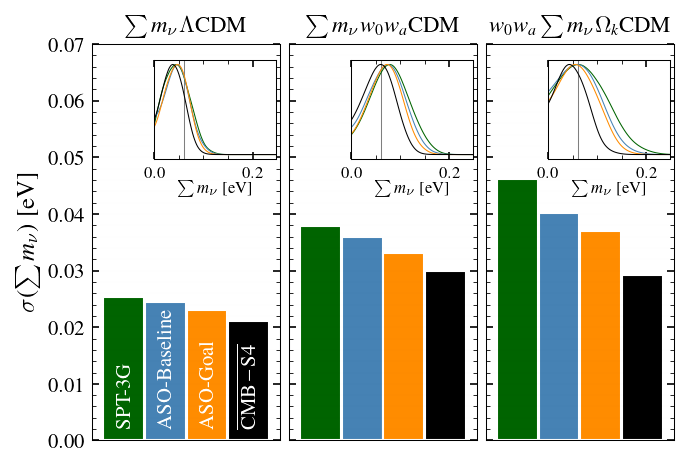

In [73]:
#chain_fd = 'chains/for_paper/20250530_wrong_lensing/'
#chain_fd = 'chains/for_paper/20250531_biased_lmaxEEissue/'
chain_fd = 'chains/for_paper/'
param_limits_dic = {'omegam': [0.28, 0.35], 
                    'w': [-1.3, -0.7], 
                    'wa': [-0.6, 0.5], 
                    'mnu': [0., 0.24], 
                    'logA': [3.01, 3.1], 
                    'ns': [0.94, 0.99], 
                    'ombh2': [0.022, 0.0227], 
                    'omch2': [0.116, 0.128], 
                    'tau': [0.035, 0.08], 
                    'H0': [66., 69.], 
                   }    
param_limits_dic_zoomed = {'omegam': [0.28, 0.35], 
                    'w': [-1.1, -0.8], 
                    'wa': [-0.8, 0.5], 
                    'mnu': [0., 0.24], 
                   }


cosmo_iter_dic = {
#                   'lcdm': ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0'], 
#                   'omklcdm': ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0', 'omk'], 
                   'mnulcdm': ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0', 'mnu'], 
#                   'nefflcdm': ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0', 'nnu'], 
                   'w0walcdm': ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0', 'w', 'wa'], 
#                   'neffmnulcdm': ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0', 'mnu', 'nnu'], 
                   'w0wamnulcdm': ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0', 'mnu', 'w', 'wa'], 
                   'w0waomklcdm': ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0', 'omk', 'w', 'wa'], 
                   'w0wamnuomklcdm': ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0', 'mnu', 'omk', 'w', 'wa'], 
                  }


cosmo_iter_dic = {
                   'mnulcdm': ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0', 'mnu'], 
                   'w0wamnulcdm': ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0', 'mnu', 'w', 'wa'], 
                   'w0wamnuomklcdm': ['logA', 'ns', 'ombh2', 'omch2', 'tau', 'H0', 'mnu', 'omk', 'w', 'wa'], 
                  }

if (1):
    #for posterior
    posterior_xarr_dic = {'mnu': np.arange(0., 0.25, 0.002)}
    identifer_arr = [
                     #'TTEETEPP', 
                     #'TTEETEPP+desidr2bao_mock+lssty3_sne_mock',
                     'TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock']

    sigma_dic = {}
    fom_dic = {}
    use_cov_or_atual = 'cov'
    posterior_yarr_dic = {}
    for cosmo_name in cosmo_iter_dic:
        print( 'Cosmo = %s' %(cosmo_name) )
        params_to_plot = cosmo_iter_dic[cosmo_name]
        sigma_dic[cosmo_name] = {}
        posterior_yarr_dic[cosmo_name] = {}
        fom_dic[cosmo_name] = {}
        for identifer in identifer_arr:
            print( '  identifer = %s' %(identifer) )
            sigma_dic[cosmo_name][identifer] = {}
            posterior_yarr_dic[cosmo_name][identifer] = {}
            fom_dic[cosmo_name][identifer] = {}
            #chain_search_str = '%s/s*%s-%s' %(chain_fd, identifer, cosmo_name)
            chain_search_str = '%s/[ad,s]*%s-%s' %(chain_fd, identifer, cosmo_name)
            chain_fdlist = sorted( glob.glob( chain_search_str ) )

            #print( '\tTotal chains to analyse = %s\n' %(len(chain_fdlist)) )
            if len( chain_fdlist ) == 0:
                print('\tnoting available for %s: %s\n' %(identifer, cosmo_name))
                continue

            for curr_chain_fd in chain_fdlist:
                chainname = curr_chain_fd.split('/')[-1]
                fname = '%s/%s' %(curr_chain_fd, chainname)
                chainfile = '%s.1.txt' %(fname)
                if not os.path.exists( chainfile ): continue

                curr_samples = getdist.mcsamples.loadMCSamples( fname )
                print( '\t', chainname, curr_samples.samples.shape )
                curr_samples.removeBurn(burn_in_fraction)
                
                #get the fom
                if cosmo_name in ['w0wamnulcdm', 'w0walcdm']:
                    params_for_fom = ['w', 'wa']
                elif cosmo_name == 'neffmnulcdm':
                    params_for_fom = ['mnu', 'nnu']
                elif cosmo_name == 'mnulcdm':
                    params_for_fom = ['mnu']
                cov_mat = misc_getdist.get_param_cov_mat_from_getdist(curr_samples, params_for_fom)
                fom = 1/np.sqrt( np.linalg.det(cov_mat) )
                fom_dic[cosmo_name][identifer][chainname] = fom
                
                #get the errros
                sigma_dic[cosmo_name][identifer][chainname] = {}
                posterior_yarr_dic[cosmo_name][identifer][chainname] = {}
                if use_cov_or_atual == 'actual':
                    '''
                    for pind, ppp in enumerate( params_to_plot ):
                        sigma_dic[cosmo_name][identifer][chainname][ppp] = curr_sigma_arr[pind]
                    '''
                    pass

                elif use_cov_or_atual == 'cov':
                    constraints_dic, constraints_table, colors_table, col_labels = misc_getdist.get_constraints_table(['mnu'], [curr_samples], ['black'])
                    print( cosmo_name, chainname, constraints_dic ); 
                    
                    curr_cov_mat = misc_getdist.get_param_cov_mat_from_getdist(curr_samples, params_to_plot)
                    curr_sigma_arr = np.sqrt( np.diag( curr_cov_mat ) )
                    for pind, ppp in enumerate( params_to_plot ):
                        sigma_dic[cosmo_name][identifer][chainname][ppp] = curr_sigma_arr[pind]
                        
                        if (0):##ppp == 'mnu': #replace error with upper error for mnu
                            mnu_constraints_dic, mnu_constraints_table, mnu_colors_table, mnu_col_labels = misc_getdist.get_constraints_table(['mnu'], [curr_samples])
                            curr_pp_lab, curr_sigma_upper_mnu = misc_getdist.strip_getdist_latex_str(mnu_constraints_dic['mnu'][0], what_kind_of_constraint = 'upper_error')
                            curr_pp_lab, curr_sigma_lower_mnu = misc_getdist.strip_getdist_latex_str(mnu_constraints_dic['mnu'][0], what_kind_of_constraint = 'lower_error')
                            sigma_dic[cosmo_name][identifer][chainname][ppp] = max( abs(curr_sigma_lower_mnu), abs(curr_sigma_upper_mnu) )

                        if ppp in posterior_xarr_dic:
                            density1d_obj = curr_samples.get1DDensity(ppp)
                            posterior = density1d_obj( posterior_xarr_dic[ppp] )
                            posterior_yarr_dic[cosmo_name][identifer][chainname][ppp] = posterior

#sys.exit()
'''
for cosmo_name in cosmo_iter_dic:
    for identifer in sigma_dic[cosmo_name]:
        for chainname in sigma_dic[cosmo_name][identifer]:
            print( cosmo_name, chainname, sigma_dic[cosmo_name][identifer][chainname]['mnu'])
sys.exit() 
'''

#make the figure now
all_params_to_plot = np.unique( list( chain( *(cosmo_iter_dic[cosmo_name] for cosmo_name in cosmo_iter_dic) ) ) )

"""
cosmo_label_dic = {
                  'lcdm': r'$\Lambda {\rm CDM}$', 
                  'omklcdm': r'$+\Omega_{k}$', 
                  'mnulcdm': r'$\sum m_{\nu}$', 
                  'w0walcdm': r'$+w_{0}+w_{a}$', 
                  'nefflcdm': r'$+ N_{\rm eff}$', 
                  'w0wamnulcdm': r'$\sum m_{\nu}+w_{0}+w_{a}$', 
                  'neffmnulcdm': r'$+N_{\rm eff}+\sum m_{\nu}$', 
                  'w0waomklcdm': r'$+w_{0}+w_{a}+\Omega_{k}$', 
                  'w0wamnuomklcdm': r'$+w_{0}+w_{a}+\sum m_{\nu}+\Omega_{k}$', 
                }
"""
cosmo_label_dic = {
                  'mnulcdm': r'$\sum m_{\nu} \Lambda {\rm CDM}$', 
                  'w0wamnulcdm': r'$\sum m_{\nu} w_{0} w_{a} {\rm CDM}$', 
                  'w0wamnuomklcdm': r'$w_{0} w_{a} \sum m_{\nu} \Omega_{k} {\rm CDM}$', 
                }
cmb_experiment_dic = {'spt3g': [r'SPT-3G', 'darkgreen'], 
                    ##'so_baseline': [r'SO-Baseline', 'steelblue'],
                    ##'so_goal': [r'SO-Goal', 'darkorange'],
                    'advanced_so_baseline': [r'ASO-Baseline', 'steelblue'],
                    'advanced_so_goal': [r'ASO-Goal', 'darkorange'],
                    's4_wide': [r'$\overline{\rm CMB-S4}$', 'black'],
                   }

identifier_hatch_dic = {'TTEETEPP': 'xxx', 
                  'TTEETEPP+desidr2bao_mock+lssty3_sne_mock': None, 
                  'TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock': None, 
                 }

sigma_param_mul_dic = {'omch2': 1e4, 'ombh2': 1e5, 'ns': 1000., 'H0': 1., 'As': 1e11, 'logA': 1000., 
                      'mnu': 1.,#100., 
                      'nnu': 1e2, 
                       'w': 1., 
                       'wa': 1., 
                       'omk': 100., }

#param_max_limit_dic = {'omch2': 2e-3, 'ombh2': 1.2e-4, 'ns': 8e-3, 'H0': .8, 'logA': 2.5e-2, 'mnu': 0.07}
param_max_limit_dic = {'omch2': 1.5e-3, 'ombh2': 1.2e-4, 'ns': 7e-3, 'H0': .6, 'logA': 1.7e-2, 
                      'mnu': 0.07,
                      'nnu': 0.1,
                      'w': 0.037, #0.045, 
                      'wa': 0.18,
                      'omk': 0.0015,
                      }


#xloc_and_label_dic = {}
#for expind, cmb_experiment in enumerate( cmb_experiment_dic ):
#    xloc = expind-0.5
#    xloc_and_label_dic[xloc] = cmb_experiment_dic[cmb_experiment][0]
xloc_and_label_dic = {}
xloc_and_label_dic[-0.5] = r'CMB'
xloc_and_label_dic[3.5] = r'+SNe+BAO'

def get_cosmologies_to_plot_for_param(ppp):
    if ppp in ['logA', 'ns', 'ombh2', 'omch2', 'H0']:
        cosmo_arr_to_plot = ['lcdm', 'omklcdm', 'mnulcdm', 'nefflcdm', 'w0walcdm', 'neffmnulcdm', 'w0wamnulcdm', 'w0waomklcdm']
    elif ppp in ['mnu']:
        #cosmo_arr_to_plot = ['mnulcdm', 'neffmnulcdm', 'w0wamnulcdm']
        cosmo_arr_to_plot = ['mnulcdm', 'w0wamnulcdm', 'w0wamnuomklcdm']
    elif ppp in ['omk']:
        cosmo_arr_to_plot = ['omklcdm', 'w0waomklcdm']
    elif ppp in ['nnu']:
        cosmo_arr_to_plot = ['nefflcdm', 'neffmnulcdm']
    elif ppp in ['w', 'wa', 'ws', 'w0']:
        cosmo_arr_to_plot = ['w0walcdm', 'w0wamnulcdm', 'w0waomklcdm']
    return cosmo_arr_to_plot

all_params_to_plot_dic = {
                         #'lcdm_params': np.asarray( ['logA', 'ns', 'ombh2', 'omch2', 'H0'] ),
                         #'darkenergy_params': np.asarray( ['w', 'wa'] ),
                         'mnu_params': np.asarray( ['mnu'] ),
                         #'extensions_params': np.asarray( ['mnu', 'nnu', 'omk'] ),
                         #'extensions_params': np.asarray( ['omk', 'nnu'] ),
                         }


####################################
#print FoM
print('\n')
#cosmo_name_arr = ['w0walcdm', 'w0wamnulcdm', 'w0waomklcdm']
cosmo_name_arr = ['mnulcdm', 'w0wamnulcdm']
#reqd_identifer = 'TTEETEPP+desidr2bao_mock+lssty3_sne_mock'
reqd_identifer = 'TTEETEPP+desidr3bao_lowz_mock+desidr3bao_highz_mock+lssty3_sne_mock'
for expind, cmb_experiment in enumerate( cmb_experiment_dic ):
    for cosmo_name in cosmo_name_arr:
        chainname = '%s-%s-%s' %(cmb_experiment, identifer, cosmo_name)
        print(cosmo_name, chainname, '%.2f' %(fom_dic[cosmo_name][reqd_identifer][chainname]))
    print('\n')
print('\n')
#sys.exit()

####################################

for all_params_to_plot_key in all_params_to_plot_dic:
    all_params_to_plot = all_params_to_plot_dic[all_params_to_plot_key]
    close('all')
    clf()
    fsval = 12
    if all_params_to_plot_key == 'lcdm_params':
        figure( figsize = (10, 10) )
        subplots_adjust(wspace = 0.05)
        tr, tc = len(all_params_to_plot), len( cosmo_iter_dic )
    elif all_params_to_plot_key == 'darkenergy_params':
        #figure( figsize = (10, 4.) )
        subplots_adjust(wspace = 0.05, hspace = 0.3)
        tr, tc = len(all_params_to_plot), 3 #len( cosmo_iter_dic )
    elif all_params_to_plot_key == 'mnu_params':
        #figure( figsize = (6., 3.5) )
        #subplots_adjust(wspace = 0.05, hspace = 0.3)
        #tr, tc = 1, 3 #len( cosmo_iter_dic )
        figure( figsize = (5., 3.5) )
        subplots_adjust(wspace = 0.05, hspace = 0.3)
        tr, tc = 1, 3
        print(tr, tc)
    elif all_params_to_plot_key == 'extensions_params':
        figure( figsize = (5., 4.8) )
        subplots_adjust(wspace = 0.05, hspace = 0.2)
        tr, tc = len(all_params_to_plot), 2 #len( cosmo_iter_dic )

    for pind, ppp in enumerate( all_params_to_plot ):
        curr_mul_fac = sigma_param_mul_dic[ppp]
        #print(ppp)
        cosmo_arr_to_plot = get_cosmologies_to_plot_for_param(ppp)
        for cind, cosmo_name in enumerate( cosmo_arr_to_plot ):
            #print(cosmo_name, '\n')
            ax = subplot2grid( (tr, tc), (pind, cind) )
            xval = 0
            for iind, identifer in enumerate( identifer_arr ):
                #print(identifer)
                curr_sigma_arr = []
                for cmb_experiment in cmb_experiment_dic: #sigma_dic[cosmo_name][identifer]:
                    chainname = '%s-%s-%s' %(cmb_experiment, identifer, cosmo_name)
                    curr_sigma_val = None 
                    if chainname in sigma_dic[cosmo_name][identifer]:
                        if ppp in sigma_dic[cosmo_name][identifer][chainname]:
                            curr_sigma_val = sigma_dic[cosmo_name][identifer][chainname][ppp]
                            curr_sigma_val = curr_sigma_val * curr_mul_fac

                    if curr_sigma_val is not None:
                        bar( xval, curr_sigma_val, width = 0.98, 
                            color = cmb_experiment_dic[cmb_experiment][1],
                            edgecolor = 'white',
                            hatch = identifier_hatch_dic[identifer],
                           )
                    curr_sigma_arr.append( curr_sigma_val )
                    
                    xval += 1

                xval += 1
                
                #print( ppp, curr_sigma_arr)
                
            xticks([])
            if pind == len(all_params_to_plot)-1: #xaxis labels
                yloc = -0.15
                for xloc in xloc_and_label_dic:
                    xlabelval = xloc_and_label_dic[xloc]
                    #text(xloc, yloc, xlabelval, fontsize = 10)#, rotation = 45.)
            else:
                setp(ax.get_xticklabels(), visible=False)

            if cind>0: #yaxislabel
                setp(ax.get_yticklabels(), visible=False)
            else:
                #ylabval = r'$\sigma(%s)$' %(misc_getdist.get_cobaya_latex_for_plotting(ppp))
                if curr_mul_fac == 1:
                    ylabval = r'$\sigma$(%s)' %(misc_getdist.get_latex_param_str(ppp))
                    if ppp == 'mnu':
                        ylabval = '%s [eV]' %(ylabval)
                else:
                    if ppp == 'mnu':
                        ylabval = r'%s [$10^{%g}$ eV]' %(misc_getdist.get_latex_param_str(ppp), np.log10(curr_mul_fac))
                    else:
                        ylabval = r'%s [$10^{%g}$]' %(misc_getdist.get_latex_param_str(ppp), np.log10(curr_mul_fac))
                ylabel(ylabval, fontsize = fsval)

            write_title = False
            if all_params_to_plot_key == 'lcdm_params': #title
                if pind == 0:
                    write_title = True
            else:
                write_title = True
                
            if write_title:
                if all_params_to_plot_key == 'lcdm_params':
                    title_val = r'%s' %(cosmo_label_dic[cosmo_name])
                else:
                    #title_val = r'%s + $\Lambda {\rm CDM}$' %(cosmo_label_dic[cosmo_name])
                    if (0):##cosmo_name == 'mnulcdm':
                        title_val = r'$\Lambda {\rm CDM}+$%s' %(cosmo_label_dic[cosmo_name])
                    else:
                        title_val = r'%s' %(cosmo_label_dic[cosmo_name])
                    title_val = title_val.replace('$+', '$')
                title(title_val, fontsize = fsval-1) 

            ymin, ymax = 0, param_max_limit_dic[ppp] * curr_mul_fac
            ylim(ymin, ymax)
            xlim(-0.75, xval - 1.25)
            grid(True, which = 'both', lw = 0.1, alpha = 0.05, zorder = -100)
            
            #write legend
            if all_params_to_plot_key in ['darkenergy_params', 'extensions_params', 'mnu_params']: 
                if pind == 0 and cind == 0:
                    for expind, cmb_experiment in enumerate( cmb_experiment_dic ):
                        labval, colorval = cmb_experiment_dic[cmb_experiment]
                        if all_params_to_plot_key == 'mnu_params':
                            yloc = ymax * 0.04
                            textfsval = fsval-0.5-1.5
                        else:
                            yloc = ymax * 0.1
                            textfsval = fsval-1
                        #text(expind-0.2, yloc, r'{\bf %s}' %(labval), color = 'white', 
                        text(expind-0.2, yloc, r'%s' %(labval), color = 'white', 
                             rotation = 90.,
                             fontsize = textfsval,
                            )

            elif all_params_to_plot_key == 'lcdm_params': 
                '''
                if pind == 0 and cind == 0:
                    for expind, cmb_experiment in enumerate( cmb_experiment_dic ):
                        labval, colorval = cmb_experiment_dic[cmb_experiment]
                        text(expind-0.2, yloc, r'%s' %(labval), color = 'white', 
                             rotation = 90.,
                             fontsize = fsval-1,
                            )
                '''
                if pind == 0 and cind == 4:
                    for expind, cmb_experiment in enumerate( cmb_experiment_dic ):
                        labval, colorval = cmb_experiment_dic[cmb_experiment]
                        bar( 0., 0., width = 0.98, 
                            color = colorval,
                            #edgecolor = 'white',
                            #hatch = identifier_hatch_dic[identifer],
                            label = labval,
                           )
                        legend(bbox_to_anchor = (0.3, 1.01), ncol = 4, 
                               fontsize = fsval-2, handlelength = 1, 
                               handletextpad = 0.5,
                              framealpha = 1.)
            elif (0):#all_params_to_plot_key == 'extensions_params': 
                ax = subplot2grid((tr, tc), (1, 2))
                for cmb_experiment in cmb_experiment_dic:
                    labval, colorval = cmb_experiment_dic[cmb_experiment]
                    bar( 0., 0., width = 0.98, 
                        color = colorval,
                        #edgecolor = 'white',
                        #hatch = identifier_hatch_dic[identifer],
                        label = labval,
                       )
                    legend(bbox_to_anchor = (0.98, 1.2), ncol = 1, 
                           fontsize = fsval, handlelength = 1.2, 
                           handletextpad = 0.5,
                          framealpha = 1.) 
                axis('off')
                
            #add posteriors in inset, if need be
            if ppp in posterior_xarr_dic:
                #ax2 = misc_getdist.add_subplot_axes(ax,[0.2, 0.71, 0.65, 0.25],axisbg='w')
                ax2 = misc_getdist.add_subplot_axes(ax,[0.33, 0.71, 0.65, 0.25],axisbg='w')
                tickfsval = fsval - 4
                xarr = posterior_xarr_dic[ppp]
                for cmb_experiment in cmb_experiment_dic:
                    chainname = '%s-%s-%s' %(cmb_experiment, identifer, cosmo_name)
                    yarr = posterior_yarr_dic[cosmo_name][identifer][chainname][ppp]
                    plot(xarr, yarr, color = cmb_experiment_dic[cmb_experiment][1], lw = 0.5)
                    yticks([])
                axvline(param_dict[ppp], lw = 0.5, alpha = 0.5, color = 'black', zorder = -100)
                xmin, xmax = min(xarr), max(xarr)
                ax2.set_xlim(xmin, xmax * 1.)
                ax2.xaxis.set_tick_params(labelsize=tickfsval)
                ax2.yaxis.set_tick_params(labelsize=tickfsval)
                xlabval = r'%s' %(misc_getdist.get_latex_param_str(ppp))
                if ppp == 'mnu':
                    xlabval = '%s [eV]' %(xlabval)
                ax2.set_xlabel(xlabval, fontsize = tickfsval, labelpad = -0.5)

    all_params_to_plot_str = '-'.join( all_params_to_plot )
    plname = 'plots/whisker_for_%s.pdf' %(all_params_to_plot_str)
    #plname = 'plots/png/whisker_for_%s.png' %(all_params_to_plot_str)
    savefig(plname, dpi = 200.)
    show()
            

# Compare with Fisher results
## CMB.
## SNe Fisher vs MCMC; Also old vs latest.
## Compare constraints from different binning schemes

In [ ]:
##fisher_colorval = 'brown' ##tab:brown' #black'
##mcmc_colorval = 'goldenrod'
##fisher_colorval = 'black'
##mcmc_colorval = 'palevioletred'
param_dict['Astaucomb'] = param_dict['As'] * np.exp( -2*param_dict['tau'] )
chain_fd = 'chains/for_paper/20250614_something_is_wrong/'
#chain_fd = 'chains/for_paper/'
which_cosmo = 'lcdm'

if which_cosmo == 'lcdm':
    fix_params = ['ws', 'wa', 'mnu', 'neff', 'nrun']
    params_to_plot = ['logA', 'H0', 'ns', 'ombh2', 'omch2']#, 'tau']
elif which_cosmo == 'w0walcdm':
    fix_params = ['mnu', 'neff', 'nrun']
    params_to_plot = ['logA', 'H0', 'ns', 'ombh2', 'omch2', 'w', 'wa']#, 'mapTCal1']

fisher_fname = 'results/fisher/cmbs4_cmb_fisher_lensed_scalar_params--As--h--ns--omch2--ombh2--tau--ws--wa--mnu--neff--nrun_lmint300--lminp300--lmaxt3500--lmaxp3500_fsky0.57.npy'
fisher_dic = np.load( fisher_fname, allow_pickle=True).item()
f_mat = fisher_dic['fisher_matrix']
fisher_params = fisher_dic['params']
fisher_param_labels = []
for ppp in fisher_params:
    fisher_param_labels.append( misc_getdist.get_cobaya_latex(ppp) )

#get Gaussian mix
prior_dic = {'tau': 0.007}
gauss_mix = misc_getdist.get_gauss_mix_from_fisher(param_dict, f_mat, fisher_params, fisher_param_labels, fix_params = fix_params, prior_dic = prior_dic)

#get samples
mix_samples = misc_getdist.get_gaussian_mix_from_getdist(gauss_mix, label = 'Fisher')

#add derived params
p = mix_samples.getParams()
paramnames = mix_samples.getParamNames()
mix_samples.addDerived(p.h * 100., name='H0', label=r'H_0')
mix_samples.addDerived(np.log(p.As * 1e10), name='logA', label=r'\log(10^{10} A_\mathrm{s})')
mix_samples.addDerived(p.As * np.exp(-2*p.tau), name='Astaucomb', label=r'A_\mathrm{s} e^{-2\tau}')
if which_cosmo == 'w0walcdm':
    mix_samples.addDerived(p.ws, name='w', label=r'w_{0}')

#-------------------------------------------------------
#-------------------------------------------------------
#------------CMB
#-------------------------------------------------------
#-------------------------------------------------------

fisher_colorval = 'grey'
fisher_filled = False #True
mcmc_colorval = 'black'
#which_cosmo = 'w0walcdm'
#chain_search_str = '%s/*-lcdm' %(chain_fd)
#chain_search_str = '%s/20250522_fixed/s4_wide*-lcdm_calfixed' %(chain_fd)
#chain_search_str = '%s/20250610_checks/s4_wide*-lcdm*_calfixed' %(chain_fd)
chain_search_str = '%s/s4_wide*-%s*_calfixed' %(chain_fd, which_cosmo)
chain_fdlist = glob.glob( chain_search_str )
#chain_fdlist.append( 'chains/for_paper//s4_wide-TTEETE-%s' %(which_cosmo))
# chain_fdlist.append( 'chains/for_paper/20250605_biased/s4_wide-TTEETE-lcdm_calfixed')
# chain_fdlist.append( 'chains/for_paper/20250605_biased/s4_wide-TTEETE-lcdm_deltael200_calfixed')
# chain_fdlist.append( 'chains/for_paper/20250605_biased/s4_wide-TTEETE-lcdm_deltael50_calfixed')
###print(chain_fdlist); sys.exit()

print('Total chains to analyse = %s\n' %(len(chain_fdlist)))

samples_dic = {}
for curr_chain_fd in chain_fdlist:
    chainname = curr_chain_fd.split('/')[-1]
    if chainname.find('+')>-1: continue
    if chainname.find('PP')>-1: continue
    if chainname.find('lsst')>-1 or chainname.find('desi')>-1: continue
        
    ##print(chainname)
    fname = '%s/%s' %(curr_chain_fd, chainname)
    chainfile = '%s.1.txt' %(fname)
    if not os.path.exists( chainfile ): continue
        
    curr_samples = getdist.mcsamples.loadMCSamples( fname )
    if (0):##fname.find('s4_wide-TTEETE-lcdm_deltael200_calfixed')>-1:
        curr_samples.removeBurn(burn_in_fraction*1.2)
    else:
        curr_samples.removeBurn(burn_in_fraction)
    
    if curr_chain_fd.find('20250605_biased')>-1:
        chainname = '20250605_biased_%s' %(chainname)
    samples_dic[chainname] = curr_samples
    print( chainname, curr_samples.samples.shape )
    
#print('Total chains analysed = %s\n' %(len(samples_dic))); sys.exit()

#plot
chains_to_plot = [
                  #'s4_wide-TTEETE-%s' %(which_cosmo), 
                  ###'s4_wide-TTEETE-%s_deltael50_calfixed' %(which_cosmo), 
                  's4_wide-TTEETE-%s_calfixed' %(which_cosmo), 
                  ###'s4_wide-TTEETE-%s_deltael200_calfixed' %(which_cosmo), 
                  #'20250605_biased_s4_wide-TTEETE-%s_deltael50_calfixed' %(which_cosmo),
                  #'20250605_biased_s4_wide-TTEETE-%s_calfixed' %(which_cosmo),
                  #'20250605_biased_s4_wide-TTEETE-%s_deltael200_calfixed' %(which_cosmo),
                 ]

samples_to_plot, labels_arr = [], []
if 'tau' in params_to_plot:
    fom_scale_fac = 1. #1e18
else:
    fom_scale_fac = 1. #1e14
    
param_dict['Astaucomb'] = param_dict['As'] * np.exp( -2*param_dict['tau'] )


if (1): #Fisher first
    cov_mat = misc_getdist.get_param_cov_mat_from_getdist(mix_samples, params_to_plot)
    fisher_fom = 1/np.sqrt( np.linalg.det(cov_mat) ) / fom_scale_fac
    print( 'fisher', fisher_fom)


    samples_to_plot.append( mix_samples )
    #labels_arr.append( 'CMB-S4 $TT/EE/TE$ (Unbinned Fisher): FoM = %.3g' %(fisher_fom) )
    labels_arr.append( 'CMB-S4 (Unbinned Fisher): FoM = %.3g' %(fisher_fom) )

for chainname in chains_to_plot:
    chain_label = misc_getdist.get_chain_label(chainname, remove_cmb_datachars = True)
    chain_label = chain_label.replace('_calfixed', '')
    tmpsplit = chain_label.split('_')
    ##print(tmpsplit)
    if len(tmpsplit)==2:
        chain_label, delta_el_val = tmpsplit
        delta_el_val = int( delta_el_val.replace('deltael', '' ) )
    else:
        delta_el_val = 100
        chain_label = tmpsplit[0]
    binning_label = r'$\Delta_{\ell}$ = %s' %(delta_el_val)
    #chain_label = '%s $TT/EE/TE$ (%s)' %(chain_label, binning_label)
    chain_label = '%s (%s)' %(chain_label, binning_label)
    #print(chain_label, binning_label); sys.exit()
    curr_samples = samples_dic[chainname]

    #add derived params
    p = curr_samples.getParams()
    paramnames = curr_samples.getParamNames()
    curr_samples.addDerived(p.As * np.exp(-2*p.tau), name='Astaucomb', label=r'A_\mathrm{s} e^{-2\tau}')
    
    
    cov_mat = misc_getdist.get_param_cov_mat_from_getdist(curr_samples, params_to_plot)
    fom = 1/np.sqrt( np.linalg.det(cov_mat) ) / fom_scale_fac
    paramnames = curr_samples.getParamNames()
    paramnames_latex = curr_samples.getLatex()
    ##print(paramnames)

    
    samples_to_plot.append( curr_samples )
    labels_arr.append( '%s: FoM = %.3g' %(chain_label, fom) )
    print( chain_label, fom, fisher_fom / fom)
    #labels_arr.append( r'CMB-S4: MCMC' )    
    
clf()
param_limits_dic = {'omegam': [0.28, 0.35], 
                    'w': [-1.3, -0.7], 
                    'wa': [-0.6, 0.5], 
                    'mnu': [0., 0.24], 
                    'logA': [3.01, 3.1], 
                    'ns': [0.95, 0.98], 
                    'ombh2': [0.0222, 0.0225], 
                    'omch2': [0.117, 0.124], 
                    'tau': [0.035, 0.08], 
                    'H0': [66., 68.5], 
                   }    
g = misc_getdist.make_getdist_plot('triangle', 
                                   samples_to_plot, 
                                   params_to_plot, 
                                   param_dict = param_dict, 
                                   color_arr = [fisher_colorval, mcmc_colorval],
                                   figsize = 4.1, fsval = 14,
                                   legloc = 'upper right',
                                   legfsval = 13.,
                                   labels = labels_arr,
                                   filled = [fisher_filled, True],
                                   param_limits_dic = param_limits_dic,
                                   write_errors_on_diagonal = True,
                                   diagonal_errors_fsval = 4,
                                   #color_arr = ['black', 'steelblue', 'darkgreen', 'orangered'],
                                   #figsize = 7.5, fsval = 14, leg_fsval = 16,
                                  )
plname = 'plots/cmbs4_%s_mcmc_fisher.pdf' %(which_cosmo)
savefig(plname, dpi = 200.)
show()

#-------------------------------------------------------
#-------------------------------------------------------
#------------Binning effects
#-------------------------------------------------------
#-------------------------------------------------------

"""
#which_cosmo = 'w0walcdm'
chain_search_str = '%s/s4_wide*-%s*_calfixed' %(chain_fd, which_cosmo)
chain_fdlist = glob.glob( chain_search_str )
#chain_fdlist.append( 'chains/for_paper//s4_wide-TTEETE-%s' %(which_cosmo))

print('Total chains to analyse = %s\n' %(len(chain_fdlist)))

samples_dic = {}
for curr_chain_fd in chain_fdlist:
    chainname = curr_chain_fd.split('/')[-1]
    if chainname.find('+')>-1: continue
    if chainname.find('PP')>-1: continue
    if chainname.find('lsst')>-1 or chainname.find('desi')>-1: continue
        
    ##print(chainname)
    fname = '%s/%s' %(curr_chain_fd, chainname)
    chainfile = '%s.1.txt' %(fname)
    if not os.path.exists( chainfile ): continue
        
    curr_samples = getdist.mcsamples.loadMCSamples( fname )
    curr_samples.removeBurn(burn_in_fraction)
    if curr_chain_fd.find('20250605_biased')>-1:
        chainname = '20250605_biased_%s' %(chainname)
    samples_dic[chainname] = curr_samples
    print( chainname, curr_samples.samples.shape )
    
#print('Total chains analysed = %s\n' %(len(samples_dic))); sys.exit()
"""

#plot
chains_to_plot = [
                  's4_wide-TTEETE-%s_deltael50_calfixed' %(which_cosmo), 
                  's4_wide-TTEETE-%s_calfixed' %(which_cosmo), 
                  's4_wide-TTEETE-%s_deltael200_calfixed' %(which_cosmo), 
                 ]

if which_cosmo == 'lcdm':
    fix_params = ['ws', 'wa', 'mnu', 'neff', 'nrun']
    params_to_plot = ['logA', 'H0', 'ns', 'ombh2', 'omch2']#, 'tau']
    #params_to_plot = ['As', 'H0', 'ns', 'ombh2', 'omch2']#, 'tau']
    #fisher_param_labels = ['A_\\mathrm{s}', 'H_0' , 'n_\\mathrm{s}', '\\Omega_\\mathrm{b} h^2', '\\Omega_\\mathrm{c} h^2', '\\tau_\\mathrm{reio}']
    fisher_param_labels = [r'\log(10^{10} A_\mathrm{s})', 'H_0' , 'n_\\mathrm{s}', '\\Omega_\\mathrm{b} h^2', '\\Omega_\\mathrm{c} h^2', '\\tau_\\mathrm{reio}']
elif which_cosmo == 'w0walcdm':
    fix_params = ['mnu', 'neff', 'nrun']
    #params_to_plot = ['logA', 'H0', 'ns', 'ombh2', 'omch2', 'tau', 'w', 'wa']#, 'mapTCal1']
    params_to_plot = ['logA', 'H0', 'ns', 'ombh2', 'omch2', 'w', 'wa']#, 'mapTCal1']
    fisher_param_labels = [r'\log(10^{10} A_\mathrm{s})', 'H_0' , 'n_\\mathrm{s}', '\\Omega_\\mathrm{b} h^2', '\\Omega_\\mathrm{c} h^2', '\\tau_\\mathrm{reio}', 'w_{0}', 'w_{a}']

samples_to_plot, labels_arr = [], []
param_cov_mat_arr = []
if 'tau' in params_to_plot:
    fom_scale_fac = 1. #1e18
else:
    fom_scale_fac = 1. #1e14
    

if (1): #Fisher first
    cov_mat = misc_getdist.get_param_cov_mat_from_getdist(mix_samples, params_to_plot)
    fisher_fom = 1/np.sqrt( np.linalg.det(cov_mat) ) / fom_scale_fac
    print( 'fisher', fisher_fom)


    samples_to_plot.append( mix_samples )
    labels_arr.append( 'CMB-S4 (Unbinned Fisher): FoM = %.3g' %(fisher_fom) )


for chainname in chains_to_plot:
    chain_label = misc_getdist.get_chain_label(chainname, remove_cmb_datachars = True)
    chain_label = chain_label.replace('_calfixed', '')
    tmpsplit = chain_label.split('_')
    ##print(tmpsplit)
    if len(tmpsplit)==2:
        chain_label, delta_el_val = tmpsplit
        delta_el_val = int( delta_el_val.replace('deltael', '' ) )
    else:
        delta_el_val = 100
        chain_label = tmpsplit[0]
    binning_label = r'$\Delta_{\ell}$ = %s' %(delta_el_val)
    chain_label = '%s $TT/EE/TE$ (%s)' %(chain_label, binning_label)
    #print(chain_label, binning_label); sys.exit()
    curr_samples = samples_dic[chainname]

    '''
    #add derived params
    p = curr_samples.getParams()
    paramnames = curr_samples.getParamNames()
    curr_samples.addDerived(p.As * np.exp(-2*p.tau), name='Astaucomb', label=r'A_\mathrm{s} e^{-2\tau}')
    '''
    
    cov_mat = misc_getdist.get_param_cov_mat_from_getdist(curr_samples, params_to_plot)
    param_cov_mat_arr.append( cov_mat )
    fom = 1/np.sqrt( np.linalg.det(cov_mat) ) / fom_scale_fac
    paramnames = curr_samples.getParamNames()
    paramnames_latex = curr_samples.getLatex()
    
    samples_to_plot.append( curr_samples )
    labels_arr.append( '%s: FoM = %.3g' %(chain_label, fom) )
    print( chain_label, fom, fisher_fom / fom)
    #labels_arr.append( r'CMB-S4: MCMC' )        
        
#whisker plots for different binning schemes.
labels_arr_mod = ['Fisher (Unbinned)', '$\Delta_{\ell}$ = 50', '$\Delta_{\ell}$ = 100', '$\Delta_{\ell}$ = 200']
sigma_param_mul_dic = {'omch2': 1e4, 'ombh2': 1e5, 'ns': 1000., 'H0': 1., 'As': 1e11, 'logA': 1000.}
#color_arr = [fisher_colorval, 'steelblue', mcmc_colorval, 'darkred']
color_arr = [fisher_colorval, 'steelblue', mcmc_colorval, 'darkred']
clf()
print(params_to_plot)
fsval = 14
ax = misc_getdist.make_whisker(samples_to_plot, 
                              params_to_plot, 
                              param_dict = param_dict, 
                              labels_arr = labels_arr_mod,
                              color_arr = color_arr,
                              fsval = fsval, alphaval = 0.8, 
                              sigma_param_mul_dic = sigma_param_mul_dic,
                              plot_kind = 'ratio',
                              show_table = True,
                              )
title(r'CMB-S4: $TT/EE/TE$', fontsize = fsval + 2)
plname = 'plots/cmbs4_%s_mcmc_fisher_elbinning.pdf' %(which_cosmo)
#plname = 'plots/png/cmbs4_%s_mcmc_fisher_elbinning.png' %(which_cosmo)
savefig(plname, dpi = 200.)
show(); ##sys.exit()



#-------------------------------------------------------
#-------------------------------------------------------
#------------SNe
#-------------------------------------------------------
#-------------------------------------------------------

mcmc_colorval = 'palevioletred'
which_cosmo = 'w0walcdm'
#which_cosmo = 'lcdm'
other_mcmc_fd = '/Users/sraghunathan/Research/cobaya/desi/chains/'
chain_fdlist = [#'chains/for_paper/lssty3_sne_mock-%s' %(which_cosmo), 
                '%s/lssty3snesim1_%s' %(other_mcmc_fd, which_cosmo), 
                ]

samples_dic = {}
for curr_chain_fd in chain_fdlist:
    chainname = curr_chain_fd.split('/')[-1]
    print(chainname)
    fname = '%s/%s' %(curr_chain_fd, chainname)
    chainfile = '%s.1.txt' %(fname)
    if not os.path.exists( chainfile ): continue
        
    curr_samples = getdist.mcsamples.loadMCSamples( fname )
    curr_samples.removeBurn(burn_in_fraction)
    samples_dic[chainname] = curr_samples
    print( chainname, curr_samples.samples.shape )
    
print('Total chains analysed = %s\n' %(len(samples_dic))); #sys.exit()

#plot
#params_to_plot = ['omegam', 'w', 'wa']
if which_cosmo == 'w0walcdm':
    params_to_plot = ['omch2', 'w', 'wa']
elif which_cosmo == 'lcdm':
    params_to_plot = ['omch2', 'w', 'wa']
#params_to_plot = ['omch2v2', 'w', 'wa']
chains_to_plot = [
                  #'lssty3_sne_mock-%s' %(which_cosmo),
                  'lssty3snesim1_%s' %(which_cosmo), 
                 ]

fom_scale_fac = 1.
samples_to_plot, labels_arr = [], []

if (1): #add Fisher
    sne_fisher_fd = '/Users/sraghunathan/Research/SPTpol/analysis/git/CMB_SNIa_3x2pt_Fisher/results/lsst_unbinned/'
    sne_fisher_fname = '%s/lsst_unbinned_sne_fisher_params--omch2--ws--wa--M--alpha--beta_zbins--z0.0-z0.4--z0.0-z0.6--z0.0-z1.0--z0.0-z3.0_sim1.npy' %(sne_fisher_fd)
    sne_lsst_cov_tag, sne_lsst_z_tag = 0, 3
    sne_fix_params = ['alpha', 'beta']
    sne_fisher_mat, sne_params = np.load(sne_fisher_fname, allow_pickle=True).item()[sne_lsst_cov_tag][sne_lsst_z_tag]
    sne_fisher_mat, sne_params = misc.fix_params(sne_fisher_mat, sne_params, sne_fix_params)
    sne_params[1] = 'w'
    param_dict['w'] = param_dict['ws']
    sne_param_labels = ['\\Omega_\\mathrm{c} h^2', 'w_0', 'w_a', 'M']
    gauss_mix = misc_getdist.get_gauss_mix_from_fisher(param_dict, sne_fisher_mat, sne_params, sne_param_labels, fix_params = ['M'])

    #get samples
    mix_samples = misc_getdist.get_gaussian_mix_from_getdist(gauss_mix, label = 'Fisher')

    #add derived params
    p = mix_samples.getParams()
    paramnames = mix_samples.getParamNames()
    cov_mat = misc_getdist.get_param_cov_mat_from_getdist(mix_samples, params_to_plot)
    fisher_fom = 1/np.sqrt( np.linalg.det(cov_mat) ) / fom_scale_fac

    samples_to_plot.append( mix_samples )
    labels_arr.append( 'LSST-Y3 SNe (Fisher): FoM = %d' %(fisher_fom) )
    ##print( sne_fisher_mat.shape, sne_params ); sys.exit()

for chainname in chains_to_plot:
    chain_label = misc_getdist.get_chain_label(chainname)
    curr_samples = samples_dic[chainname]
    p = curr_samples.getParams()
    paramnames = curr_samples.getParamNames()
    #print( paramnames )
    curr_samples.addDerived(p.omegam*(67.36/100)**2 - 0.02218, name='omch2v2', label=r'omch2')

    cov_mat = misc_getdist.get_param_cov_mat_from_getdist(curr_samples, params_to_plot)
    fom = 1/np.sqrt( np.linalg.det(cov_mat) ) / fom_scale_fac

    samples_to_plot.append( curr_samples )
    labels_arr.append( 'LSST-Y3 SNe (MCMC): FoM = %d' %(fom) )    

#sys.exit()

#print(labels_arr); sys.exit()
clf()
param_limits_dic = {'omegam': [0.1, 0.6], 'omch2': [0., 0.25], 'w': [-1.3, -0.6], 'wa': [-4, 3.]}

g = misc_getdist.make_getdist_plot('triangle', 
                                   samples_to_plot, 
                                   params_to_plot, 
                                   param_dict = param_dict, 
                                   color_arr = [fisher_colorval, mcmc_colorval],
                                   figsize = 4., fsval = 15,
                                   legloc = 'upper right',
                                   filled = [fisher_filled, True],                                   
                                   legfsval = 13,
                                   labels = labels_arr,
                                   param_limits_dic = param_limits_dic, 
                                   diagonal_errors_fsval = 8,
                                  )
plname = 'plots/lssty3sne_%s_mcmc_fisher.pdf' %(which_cosmo)
#plname = 'plots/png/lssty3sne_%s_mcmc_fisher.png' %(which_cosmo)
savefig(plname, dpi = 200.)
show()

#-------------------------------------------------------
#-------------------------------------------------------
#-------------------------------------------------------



[[ 3.44481601e-22  3.84530983e-14  2.27240060e-14 -1.02671607e-14
   2.09647194e-17  9.70101170e-14]
 [ 3.84530983e-14  6.69107616e-06  4.44197762e-06 -1.77047034e-06
   1.02611108e-08  1.18408584e-05]
 [ 2.27240060e-14  4.44197762e-06  6.13202472e-06 -1.26191083e-06
  -3.78648738e-08  8.41548384e-06]
 [-1.02671607e-14 -1.77047034e-06 -1.26191083e-06  4.77002448e-07
  -5.80942305e-10 -3.19023098e-06]
 [ 2.09647194e-17  1.02611108e-08 -3.78648738e-08 -5.80942305e-10
   1.05158418e-09 -5.26770459e-09]
 [ 9.70101170e-14  1.18408584e-05  8.41548384e-06 -3.19023098e-06
  -5.26770459e-09  2.83172383e-05]]
Total chains to analyse = 3

s4_wide-TTEETE-lcdm_calfixed (7728, 18)
s4_wide-TTEETE-lcdm_deltael200_calfixed (10248, 18)


In [171]:
print( sne_params )
gauss_mix = misc_getdist.get_gauss_mix_from_fisher(param_dict, sne_fisher_mat, sne_params, sne_param_labels, fix_params = None)

gauss_mix = misc_getdist.get_gauss_mix_from_fisher(param_dict, sne_fisher_mat, sne_params, sne_param_labels, fix_params = ['M'])


['omch2', 'w', 'wa', 'M']
[[ 1.47254563e-03 -1.13845912e-03 -4.27673725e-02  2.25620639e-04]
 [-1.13845912e-03  2.80721029e-03  2.46030797e-02  8.21417972e-05]
 [-4.27673725e-02  2.46030797e-02  1.28325239e+00 -7.47730114e-03]
 [ 2.25620639e-04  8.21417972e-05 -7.47730114e-03  8.21356588e-05]]
[[ 0.00085278 -0.0013641  -0.02222777]
 [-0.0013641   0.00272506  0.03208094]
 [-0.02222777  0.03208094  0.60254886]]


<Figure size 900x600 with 0 Axes>

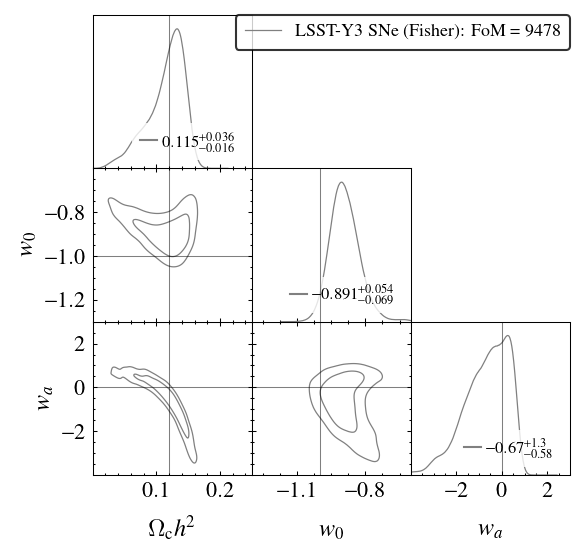

In [64]:
clf()
param_limits_dic = {'omegam': [0.1, 0.6], 'omch2': [0., 0.25], 'w': [-1.3, -0.6], 'wa': [-4, 3.]}

#params_to_plot = ['omegam', 'w', 'wa']
params_to_plot = ['omch2', 'w', 'wa']

g = misc_getdist.make_getdist_plot('triangle', 
                                   samples_to_plot, 
                                   params_to_plot, 
                                   param_dict = param_dict, 
                                   color_arr = [fisher_colorval, mcmc_colorval],
                                   figsize = 4., fsval = 15,
                                   legloc = 'upper right',
                                   filled = [fisher_filled, True],                                   
                                   legfsval = 13,
                                   labels = labels_arr,
                                   param_limits_dic = param_limits_dic, 
                                   diagonal_errors_fsval = 8,
                                  )

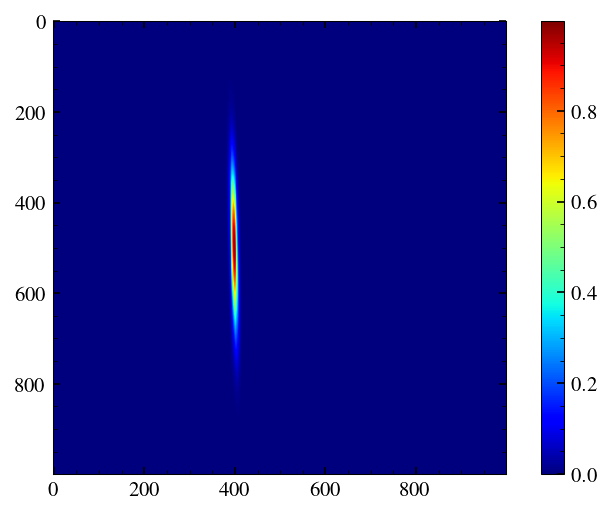

0.34143662899970706 1.7113740603407734 18.3569747572184


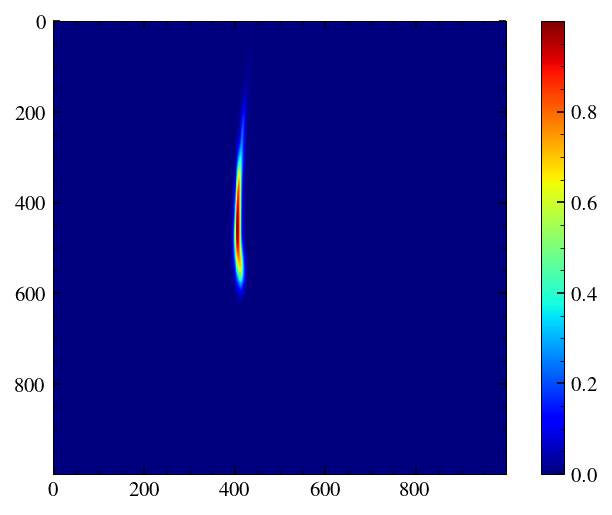

0.32443563131727465 1.7556410529995714 15.53060860117125


SystemExit: 

In [161]:
"""
clf()
g.plots_2d(curr_samples, param_pairs=[['w', 'wa']], filled=True, \
           colors=['navy', 'goldenrod', 'orangered'], #, contour_ls = ls_arr, contour_lw = lw_arr, legend_ncol = len(param_names)
           lims = [0., 0.5, -1.5, 1.],
          )
show()
"""
for curr_samples in samples_to_plot:
    params = ['w', 'wa']
    xarr, yarr, xgrid, ygrid, result_grid = misc_getdist.get_density(curr_samples, ['w', 'wa'])
    imshow(result_grid); colorbar(); show()
    dx = xarr[1] - xarr[0]
    dy = yarr[1] - yarr[0]
    grid_volume = np.sum(result_grid * dx * dy)

    """
    params = ['omch2', 'w', 'wa']
    xarr, yarr, zarr, result_grid = misc_getdist.get_density(curr_samples, ['omch2', 'w', 'wa'])
    dx = xarr[1] - xarr[0]
    dy = yarr[1] - yarr[0]
    dz = zarr[1] - zarr[0]
    grid_volume = np.sum(zgrid * dx * dy * dz)
    """
    
    cov_mat = misc_getdist.get_param_cov_mat_from_getdist(curr_samples, params)
    fom = 1/np.sqrt( np.linalg.det(cov_mat) )
    print(grid_volume, 1/np.sqrt(grid_volume), fom)

    """
    clf()
    param_limits_dic = {'omegam': [0.1, 0.6], 'omch2': [0., 0.25], 'w': [-1.3, -0.6], 'wa': [-4, 3.]}

    g.plots_2d(curr_samples, param_pairs=[['w', 'wa']], filled=True, \
               colors=['navy', 'goldenrod', 'orangered'], #, contour_ls = ls_arr, contour_lw = lw_arr, legend_ncol = len(param_names)
               lims = [-1.3, -0.6, -4., 3],
              )
    show()
    """
    
sys.exit()

clf()
#pcolormesh(xgrid, ygrid, zgrid); colorbar(); show()
ax = subplot(111)
misc.make_contour(ax, xgrid, ygrid, zgrid, threshold_arr = [0, 1, 2], color_arr = ['black', 'black', 'black'])
xlim(0., 0.5); ylim(-1.5, 1.)
show()

In [113]:
density_obj??

In [155]:
gridlen = 100
p1, p2, p3 = params
a_min, a_max = misc_getdist.get_default_param_limits_for_kde(p1)
b_min, b_max = misc_getdist.get_default_param_limits_for_kde(p2)
c_min, c_max = misc_getdist.get_default_param_limits_for_kde(p3)
a_arr = np.linspace(a_min, a_max, gridlen)
b_arr = np.linspace(b_min, b_max, gridlen)
c_arr = np.linspace(c_min, c_max, gridlen)

"""
density_obj = curr_samples.get2DDensity(p1, p2)#[0.68, 0.99])
tmp = density_obj(a_arr, b_arr)
print(tmp.shape)
sys.exit()
"""

density_obj = curr_samples.getRawNDDensity(params)#[0.68, 0.99])
#print(density_obj.P.shape)
#xs = np.asarray( [a_arr, b_arr, c_arr] )
#density_obj(xs)

from scipy.interpolate import splrep, splev, RectBivariateSpline, LinearNDInterpolator

tmp = LinearNDInterpolator(np.asarray(density_obj.xs).T[:,:2], density_obj.P.T[:, :, 0], rescale=True)


QhullError: QH6154 Qhull precision error: Initial simplex is flat (facet 1 is coplanar with the interior point)

While executing:  | qhull d Qt Qz Qc Qbb Q12
Options selected for Qhull 2019.1.r 2019/06/21:
  run-id 1516033299  delaunay  Qtriangulate  Qz-infinity-point  Qcoplanar-keep
  Qbbound-last  Q12-allow-wide  _pre-merge  _zero-centrum  Qinterior-keep
  Pgood  _max-width  1  Error-roundoff 6.9e-16  _one-merge 4.9e-15
  Visible-distance 1.4e-15  U-max-coplanar 1.4e-15  Width-outside 2.8e-15
  _wide-facet 8.3e-15  _maxoutside 5.5e-15

The input to qhull appears to be less than 3 dimensional, or a
computation has overflowed.

Qhull could not construct a clearly convex simplex from points:
- p6(v4): 0.045 0.045 2.6e-18
- p10(v3):  0.41  0.41   0.3
- p11(v2):   0.5   0.5  0.45
- p0(v1):  -0.5  -0.5  0.45

The center point is coplanar with a facet, or a vertex is coplanar
with a neighboring facet.  The maximum round off error for
computing distances is 6.9e-16.  The center point, facets

In [153]:
np.asarray(density_obj.xs).T[:][:,:2].shape

(12, 2)

In [131]:
density_obj.xs

[array([-0.07175904, -0.03791171, -0.00406439,  0.02978294,  0.06363026,
         0.09747759,  0.13132491,  0.16517223,  0.19901956,  0.23286688,
         0.26671421,  0.30056153]),
 array([-1.25028644, -1.20433657, -1.15838669, -1.11243681, -1.06648693,
        -1.02053706, -0.97458718, -0.9286373 , -0.88268742, -0.83673755,
        -0.79078767, -0.74483779]),
 array([-5.42670575, -4.44278214, -3.45885853, -2.47493492, -1.49101131,
        -0.5070877 ,  0.47683592,  1.46075953,  2.44468314,  3.42860675,
         4.41253036,  5.39645397])]

In [ ]:
# Get some random samples for demonstration:
# make random covariance, then independent samples from Gaussian
import numpy as np

"""
ndim = 2
nsamp = 10000
random_state = np.random.default_rng(10)  # seed random generator
A = random_state.random((ndim, ndim))
cov = np.dot(A, A.T)
#cov[0,1] = cov[1,0] = 0.2
samps = random_state.multivariate_normal([0] * ndim, cov, size=nsamp)

# Get the getdist MCSamples objects for the samples, specifying same parameter
# names and labels; if not specified weights are assumed to all be unity
names = ["x%s" % i for i in range(ndim)]
labels = ["x_%s" % i for i in range(ndim)]
samples = MCSamples(samples=samps, names=names, labels=labels)
"""

rho = 0.
cov_mat = [[1., rho], [rho, 1.]]
print(np.linalg.det(cov_mat))
params_mean = [1., 1.]
params = ['x0', 'x1']
names = ['x_0', 'x_1']
gauss_mix = GaussianND(params_mean, cov_mat, names=params, labels = names)
samples = misc_getdist.get_gaussian_mix_from_getdist(gauss_mix)
samples.removeBurnFraction(0.3)

# Triangle plot (sometimes also called a corner plot)
g = plots.get_subplot_plotter()
g.plots_2d(samples, param_pairs=[params], filled=True)

xarr, yarr, xgrid, ygrid, zgrid = misc_getdist.get_density(samples, 
                                                           'x0', 'x1', 
                                                           xmin = -5, xmax = 5, ymin = -5, ymax = 5.,
                                                          normalized = False, conts = 5)
dx = xarr[1] - xarr[0]
dy = yarr[1] - yarr[0]
grid_volume = np.sum(zgrid) * dx * dy
print('grid_volume = %s' %(grid_volume))

"""
xarr, yarr, xgrid, ygrid, zgrid = misc.get_kde(samples, xcol = 0, ycol = 1, xmin = -10, xmax = 10, ymin = -10, ymax = 10)
dx = xarr[1] - xarr[0]
dy = yarr[1] - yarr[0]
grid_volume = np.sum(zgrid) * dx * dy
print(grid_volume)
"""

cov_mat = misc_getdist.get_param_cov_mat_from_getdist(samples, ['x0', 'x1'])
#print(cov_mat)
fom = 1/np.sqrt( np.linalg.det(cov_mat) )
fom_v2 = 1/np.sqrt(grid_volume)
print(1/grid_volume, fom, fom_v2, fom/fom_v2)

